In [1]:
!pip install -U ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 20.7 MB/s eta 0:00:00


# 문제점 개선코드-10개 베드만 테스트

In [ ]:
# ============================================================
# Lettuce slot crop generation from best.pt (patched)
# - input : warped/front bed images
# - infer : YOLOv8-seg best.pt
# - assign: slot -> row split + Hungarian + empty 허용
# - save  : all detected pieces with slot names
# - output: crops + overlay + csv metadata
# ============================================================

# ------------------------------
# 0) 설치 (Colab 1회)
# ------------------------------
!pip -q install ultralytics openpyxl scipy tqdm

# ------------------------------
# 1) import
# ------------------------------
import os
import gc
import cv2
import math
import time
import glob
import shutil
import traceback
import numpy as np
import pandas as pd

from pathlib import Path
from tqdm.auto import tqdm
from concurrent.futures import ThreadPoolExecutor, as_completed
from scipy.optimize import linear_sum_assignment
from ultralytics import YOLO


# ============================================================
# 2) CFG (여기만 수정)
# ============================================================
MODEL_PATH = r"/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/3. ROI_LETTUCE/model/results/runs/segment/Lettuce_Final_Project/Step1_M_Model_0312/weights/best.pt"

# bed 이미지 루트(하위 폴더까지 재귀 탐색)
IMG_ROOT = r"/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/2. ROI_BOX/2작기/5. 밝기보정/260306-260412"

# 결과 저장 루트
OUT_ROOT = r"/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/3. ROI_LETTUCE/2작기_lettuce/0. crops_to260412"

# 탐색 확장자
IMG_EXTS = ("*.jpg", "*.jpeg", "*.png", "*.bmp", "*.tif", "*.tiff", "*.webp")

# 추론 옵션
IMGSZ = 960
CONF_THRES = 0.25
IOU_THRES = 0.50
DEVICE = 0          # GPU: 0 / CPU: 'cpu'
MAX_DET = 64

# crop 옵션
PAD_PX = 14
MIN_BOX_W = 20
MIN_BOX_H = 20
MASK_BG = "black"   # black | white | keep
SAVE_EXT = ".png"

# 슬롯 할당 옵션
TOP_Y = 0.22
BOT_Y = 0.72
X_POS = [0.10, 0.26, 0.42, 0.58, 0.74, 0.90]
SLOT_ORDER = [f"t{i}" for i in range(1, 7)] + [f"b{i}" for i in range(1, 7)]

# [추가] 문제 수정용 파라미터
# row 경계 근처에서 너무 빡세게 자르지 않도록 margin 사용
ROW_MARGIN = 0.08
# Hungarian 비용이 이 값보다 크면 강제 배정하지 않고 empty 처리
EMPTY_COST = 0.18
# 최근접 추가 배정 허용 거리 (이미지 대각선 비율)
EXTRA_ASSIGN_DIST_RATIO = 0.16
# 너무 작은 조각 제거
MIN_MASK_PIXELS = 80

# 저장 구조
USE_BED_SUBFOLDER = True

# 중간 저장 / 대용량 옵션
CHUNK_SIZE = 50
SAVE_EVERY_CHUNK = True
N_SAVE_WORKERS = 8
SKIP_IF_DONE = True

# 디버그/시각화
SAVE_OVERLAY = True
OVERLAY_LINE_W = 2
FONT_SCALE = 0.7


# ============================================================
# 3) 유틸
# ============================================================
def now_hms():
    return time.strftime("%H:%M:%S")


def safe_mkdir(p):
    os.makedirs(p, exist_ok=True)


def list_images_recursive(root, exts=IMG_EXTS):
    root = str(root)
    files = []
    for ext in exts:
        files.extend(glob.glob(os.path.join(root, "**", ext), recursive=True))
    files = sorted(list(set(files)))
    return files


def parse_base_key(img_path):
    return Path(img_path).stem


def parse_bed_name(base_key):
    parts = base_key.split("_")
    return parts[0] if len(parts) > 0 else "unknown_bed"


def make_slot_anchors(w, h):
    anchors = {}
    for i, xr in enumerate(X_POS, start=1):
        anchors[f"t{i}"] = (int(round(w * xr)), int(round(h * TOP_Y)))
        anchors[f"b{i}"] = (int(round(w * xr)), int(round(h * BOT_Y)))
    return anchors


def mask_to_bbox(mask_u8):
    ys, xs = np.where(mask_u8 > 0)
    if len(xs) == 0:
        return None
    x1, x2 = int(xs.min()), int(xs.max())
    y1, y2 = int(ys.min()), int(ys.max())
    return x1, y1, x2, y2


def mask_centroid(mask_u8):
    ys, xs = np.where(mask_u8 > 0)
    if len(xs) == 0:
        return None
    cx = float(xs.mean())
    cy = float(ys.mean())
    return cx, cy


def apply_mask_bg(crop_bgr, crop_mask_u8, mode="black"):
    if mode == "keep":
        return crop_bgr
    bg_val = 0 if mode == "black" else 255
    out = np.full_like(crop_bgr, bg_val)
    m = crop_mask_u8 > 0
    out[m] = crop_bgr[m]
    return out


def build_output_paths(base_key, bed_name, slot_name, part_no):
    filename = f"{base_key}_{slot_name}_p{part_no:02d}{SAVE_EXT}"
    if USE_BED_SUBFOLDER:
        out_dir = os.path.join(OUT_ROOT, "crops", bed_name)
    else:
        out_dir = os.path.join(OUT_ROOT, "crops_flat")
    safe_mkdir(out_dir)
    return os.path.join(out_dir, filename)


def box_center_from_bbox(bb):
    x1, y1, x2, y2 = bb
    return (x1 + x2) / 2.0, (y1 + y2) / 2.0


def diag_len(w, h):
    return math.hypot(w, h)


# ============================================================
# 4) 슬롯 할당 핵심 수정
# ============================================================
def split_candidates_by_row(det_infos, h):
    """
    기존 구조는 유지하되, 먼저 t/b row를 나눠서 cross-row 배정을 막음.
    너무 빡세게 자르면 잘 된 것도 날아가서 margin을 둠.
    """
    top_limit = TOP_Y + ROW_MARGIN
    bot_limit = BOT_Y - ROW_MARGIN

    t_idxs = []
    b_idxs = []

    for i, d in enumerate(det_infos):
        cy = d["cy"] / h
        if cy <= top_limit:
            t_idxs.append(i)
        elif cy >= bot_limit:
            b_idxs.append(i)
        else:
            # 애매한 영역은 더 가까운 row로 보냄
            if abs(cy - TOP_Y) <= abs(cy - BOT_Y):
                t_idxs.append(i)
            else:
                b_idxs.append(i)

    return t_idxs, b_idxs


def build_cost_matrix_row(det_infos, det_idxs, slot_names, anchors_dict, w, h):
    """
    x 거리 중심 + y 약한 penalty + conf 보정
    점(anchor)이 완벽히 맞는 게 목적이 아니라, 잘 된 80%를 유지하면서
    어색한 강제 배정만 막는 용도.
    """
    if len(det_idxs) == 0 or len(slot_names) == 0:
        return np.zeros((0, 0), dtype=np.float32)

    cost = np.zeros((len(det_idxs), len(slot_names)), dtype=np.float32)

    for r, det_idx in enumerate(det_idxs):
        d = det_infos[det_idx]
        cx = d["cx"]
        cy = d["cy"]
        conf = d["conf"]
        area = max(1, d["mask_pixels"])

        for c, slot_name in enumerate(slot_names):
            sx, sy = anchors_dict[slot_name]
            dx = abs(cx - sx) / max(1, w)
            dy = abs(cy - sy) / max(1, h)

            v = dx * 1.00 + dy * 0.35

            # conf 낮은 조각은 약간 불리하게
            if conf < 0.55:
                v += (0.55 - conf) * 0.08

            # 너무 작은 조각도 약간 불리하게
            if area < 200:
                v += 0.03

            cost[r, c] = v

    return cost


def assign_primary_slots_rowwise(det_infos, anchors_dict, w, h):
    """
    [수정 핵심]
    1) 먼저 t/b 분리
    2) 각 row 안에서 Hungarian
    3) 비용이 너무 크면 empty 허용
    => t3가 아래 b 상추 먹는 문제, 없는 t를 억지 배정하는 문제 완화
    """
    primary = {}

    t_idxs, b_idxs = split_candidates_by_row(det_infos, h)
    t_slots = [f"t{i}" for i in range(1, 7)]
    b_slots = [f"b{i}" for i in range(1, 7)]

    # top row
    if len(t_idxs) > 0:
        cost_t = build_cost_matrix_row(det_infos, t_idxs, t_slots, anchors_dict, w, h)
        if cost_t.size > 0:
            row_ind, col_ind = linear_sum_assignment(cost_t)
            for r, c in zip(row_ind, col_ind):
                det_idx = t_idxs[r]
                slot_name = t_slots[c]
                if cost_t[r, c] <= EMPTY_COST:
                    primary[det_idx] = slot_name

    # bottom row
    if len(b_idxs) > 0:
        cost_b = build_cost_matrix_row(det_infos, b_idxs, b_slots, anchors_dict, w, h)
        if cost_b.size > 0:
            row_ind, col_ind = linear_sum_assignment(cost_b)
            for r, c in zip(row_ind, col_ind):
                det_idx = b_idxs[r]
                slot_name = b_slots[c]
                if cost_b[r, c] <= EMPTY_COST:
                    primary[det_idx] = slot_name

    unassigned = [i for i in range(len(det_infos)) if i not in primary]
    return primary, unassigned


def assign_all_pieces(det_infos, anchors_dict, w, h):
    """
    모든 검출 조각에 slot 이름 부여.
    [개선]
    1) row-wise Hungarian으로 대표 슬롯(primary)만 먼저 확정
    2) 대표 슬롯은 b1~b6 / t1~t6 이 최대 1개씩만 존재
    3) 남는 조각은 대표가 이미 존재하는 슬롯에만 p02, p03...로 부착
    4) 대표가 없는 슬롯에는 조각만 덜렁 붙이지 않음
    """
    slot_of_det = {}
    part_no_of_det = {}
    is_primary_of_det = {}
    primary_slot_to_det = {s: None for s in anchors_dict.keys()}

    if len(det_infos) == 0:
        return slot_of_det, part_no_of_det, is_primary_of_det, primary_slot_to_det

    primary_map, unassigned = assign_primary_slots_rowwise(det_infos, anchors_dict, w, h)
    slot_names = list(anchors_dict.keys())
    slot_groups = {s: [] for s in slot_names}

    # 1차 배정: 대표 슬롯 고정
    for det_idx, slot_name in primary_map.items():
        slot_groups[slot_name].append(det_idx)
        slot_of_det[det_idx] = slot_name
        is_primary_of_det[det_idx] = True
        primary_slot_to_det[slot_name] = det_idx

    # 남는 조각은 "대표가 존재하는 슬롯" 중 같은 row에만 추가 배정
    dmax = diag_len(w, h) * EXTRA_ASSIGN_DIST_RATIO
    for det_idx in unassigned:
        d = det_infos[det_idx]
        cy = d["cy"] / h

        if cy <= TOP_Y + ROW_MARGIN:
            candidate_slots = [f"t{i}" for i in range(1, 7) if primary_slot_to_det[f"t{i}"] is not None]
        elif cy >= BOT_Y - ROW_MARGIN:
            candidate_slots = [f"b{i}" for i in range(1, 7) if primary_slot_to_det[f"b{i}"] is not None]
        else:
            if abs(cy - TOP_Y) <= abs(cy - BOT_Y):
                candidate_slots = [f"t{i}" for i in range(1, 7) if primary_slot_to_det[f"t{i}"] is not None]
            else:
                candidate_slots = [f"b{i}" for i in range(1, 7) if primary_slot_to_det[f"b{i}"] is not None]

        # 대표 슬롯이 하나도 없으면 추가 배정 안 함
        if len(candidate_slots) == 0:
            continue

        cx, cy_abs = d["cx"], d["cy"]
        dists = []
        for s in candidate_slots:
            sx, sy = anchors_dict[s]
            dd = math.hypot(cx - sx, cy_abs - sy)
            dists.append((s, dd))
        dists.sort(key=lambda x: x[1])

        best_slot, best_dist = dists[0]
        if best_dist <= dmax:
            slot_groups[best_slot].append(det_idx)
            slot_of_det[det_idx] = best_slot
            is_primary_of_det[det_idx] = False

    # slot 내 part 번호 부여: 대표는 항상 p01, 추가 조각은 p02부터
    for slot_name in slot_names:
        dets = slot_groups[slot_name]
        if len(dets) == 0:
            continue

        sx, sy = anchors_dict[slot_name]
        primary_det = primary_slot_to_det[slot_name]

        # 대표 det 먼저 고정
        ordered = []
        if primary_det is not None:
            ordered.append(primary_det)

        # 나머지는 앵커와 가까운 순
        extras = [i for i in dets if i != primary_det]
        extras = sorted(
            extras,
            key=lambda i: math.hypot(det_infos[i]["cx"] - sx, det_infos[i]["cy"] - sy)
        )
        ordered.extend(extras)

        for k, det_idx in enumerate(ordered, start=1):
            part_no_of_det[det_idx] = k

    return slot_of_det, part_no_of_det, is_primary_of_det, primary_slot_to_det

    primary_map, unassigned = assign_primary_slots_rowwise(det_infos, anchors_dict, w, h)
    slot_names = list(anchors_dict.keys())
    slot_groups = {s: [] for s in slot_names}

    # 1차 배정
    for det_idx, slot_name in primary_map.items():
        slot_groups[slot_name].append(det_idx)
        slot_of_det[det_idx] = slot_name
        is_primary_of_det[det_idx] = True

    # 남는 조각은 같은 row로만 최근접 추가 배정
    dmax = diag_len(w, h) * EXTRA_ASSIGN_DIST_RATIO
    for det_idx in unassigned:
        d = det_infos[det_idx]
        cy = d["cy"] / h

        if cy <= TOP_Y + ROW_MARGIN:
            candidate_slots = [f"t{i}" for i in range(1, 7)]
        elif cy >= BOT_Y - ROW_MARGIN:
            candidate_slots = [f"b{i}" for i in range(1, 7)]
        else:
            # 애매하면 더 가까운 row
            if abs(cy - TOP_Y) <= abs(cy - BOT_Y):
                candidate_slots = [f"t{i}" for i in range(1, 7)]
            else:
                candidate_slots = [f"b{i}" for i in range(1, 7)]

        cx, cy_abs = d["cx"], d["cy"]
        dists = []
        for s in candidate_slots:
            sx, sy = anchors_dict[s]
            dd = math.hypot(cx - sx, cy_abs - sy)
            dists.append((s, dd))
        dists.sort(key=lambda x: x[1])

        best_slot, best_dist = dists[0]
        if best_dist <= dmax:
            slot_groups[best_slot].append(det_idx)
            slot_of_det[det_idx] = best_slot
            is_primary_of_det[det_idx] = False

    # slot 내 part 번호 부여: 대표(primary) 우선, 그 다음 앵커와 가까운 순
    for slot_name in slot_names:
        dets = slot_groups[slot_name]
        if len(dets) == 0:
            continue

        sx, sy = anchors_dict[slot_name]
        dets_sorted = sorted(
            dets,
            key=lambda i: (
                0 if is_primary_of_det.get(i, False) else 1,
                math.hypot(det_infos[i]["cx"] - sx, det_infos[i]["cy"] - sy)
            )
        )
        for k, det_idx in enumerate(dets_sorted, start=1):
            part_no_of_det[det_idx] = k

    return slot_of_det, part_no_of_det, is_primary_of_det


# ============================================================
# 5) 저장 워커
# ============================================================
def save_crop_task(task):
    try:
        img = task["img"]
        mask = task["mask"]
        out_path = task["out_path"]
        x1, y1, x2, y2 = task["bbox"]

        if os.path.exists(out_path) and SKIP_IF_DONE:
            return {"ok": True, "out_path": out_path, "skipped": True}

        x1p = max(0, x1 - PAD_PX)
        y1p = max(0, y1 - PAD_PX)
        x2p = min(img.shape[1] - 1, x2 + PAD_PX)
        y2p = min(img.shape[0] - 1, y2 + PAD_PX)

        if (x2p - x1p + 1) < MIN_BOX_W or (y2p - y1p + 1) < MIN_BOX_H:
            return {"ok": False, "out_path": out_path, "reason": "too_small"}

        crop = img[y1p:y2p+1, x1p:x2p+1].copy()
        crop_mask = mask[y1p:y2p+1, x1p:x2p+1].copy()
        crop2 = apply_mask_bg(crop, crop_mask, MASK_BG)

        cv2.imwrite(out_path, crop2)
        return {"ok": True, "out_path": out_path, "skipped": False}

    except Exception as e:
        return {"ok": False, "out_path": task.get("out_path", ""), "reason": str(e)}


# ============================================================
# 6) overlay
# ============================================================
def draw_overlay(img, det_infos, anchors_dict):
    canvas = img.copy()

    # slot anchors (노란 점 시각화 유지)
    for slot_name, (sx, sy) in anchors_dict.items():
        cv2.circle(canvas, (int(sx), int(sy)), 8, (0, 255, 255), -1)
        cv2.putText(canvas, slot_name, (int(sx) - 16, int(sy) - 12),
                    cv2.FONT_HERSHEY_SIMPLEX, FONT_SCALE, (0, 255, 255), 2, cv2.LINE_AA)

    # detections
    for d in det_infos:
        x1, y1, x2, y2 = d["bbox"]
        slot_name = d["slot_name"]
        part_no = d["part_no"]
        is_primary = d.get("is_primary", False)

        # 대표 슬롯은 b2 / t4 처럼만 표시
        # 추가 조각은 b2_p02 / t4_p03 처럼 표시
        if is_primary:
            label = f"{slot_name}"
        else:
            label = f"{slot_name}_p{part_no:02d}"

        cv2.rectangle(canvas, (x1, y1), (x2, y2), (0, 255, 0), OVERLAY_LINE_W)
        cv2.putText(canvas, label, (x1, max(22, y1 - 6)),
                    cv2.FONT_HERSHEY_SIMPLEX, FONT_SCALE, (0, 255, 0), 2, cv2.LINE_AA)
    return canvas


# ============================================================
# 7) 단일 이미지 처리
# ============================================================
def process_one_image(img_path, model):
    base_key = parse_base_key(img_path)
    bed_name = parse_bed_name(base_key)

    img = cv2.imread(img_path)
    if img is None:
        return {
            "meta_rows": [],
            "n_det": 0,
            "n_saved": 0,
            "n_fail": 1,
            "overlay_path": None,
            "error": f"cv2.imread failed: {img_path}"
        }

    h, w = img.shape[:2]
    anchors = make_slot_anchors(w, h)

    results = model.predict(
        source=img,
        imgsz=IMGSZ,
        conf=CONF_THRES,
        iou=IOU_THRES,
        device=DEVICE,
        max_det=MAX_DET,
        retina_masks=True,
        verbose=False
    )

    if len(results) == 0:
        meta_row = {
            "image_path": img_path,
            "base_key": base_key,
            "bed_name": bed_name,
            "slot_name": None,
            "part_no": None,
            "crop_filename": None,
            "crop_path": None,
            "conf": None,
            "cls": None,
            "cx": None,
            "cy": None,
            "bbox_x1": None,
            "bbox_y1": None,
            "bbox_x2": None,
            "bbox_y2": None,
            "bbox_w": None,
            "bbox_h": None,
            "area_px": None,
            "mask_pixels": None,
            "is_primary": None,
            "n_det_in_image": 0,
            "qc_flags": "no_detection",
            "status": "no_detection"
        }
        return {
            "meta_rows": [meta_row],
            "n_det": 0,
            "n_saved": 0,
            "n_fail": 0,
            "overlay_path": None,
            "error": None
        }

    r = results[0]

    if r.masks is None or r.boxes is None or len(r.boxes) == 0:
        meta_row = {
            "image_path": img_path,
            "base_key": base_key,
            "bed_name": bed_name,
            "slot_name": None,
            "part_no": None,
            "crop_filename": None,
            "crop_path": None,
            "conf": None,
            "cls": None,
            "cx": None,
            "cy": None,
            "bbox_x1": None,
            "bbox_y1": None,
            "bbox_x2": None,
            "bbox_y2": None,
            "bbox_w": None,
            "bbox_h": None,
            "area_px": None,
            "mask_pixels": None,
            "is_primary": None,
            "n_det_in_image": 0,
            "qc_flags": "no_mask_or_box",
            "status": "no_mask_or_box"
        }
        return {
            "meta_rows": [meta_row],
            "n_det": 0,
            "n_saved": 0,
            "n_fail": 0,
            "overlay_path": None,
            "error": None
        }

    xyxy = r.boxes.xyxy.detach().cpu().numpy()
    confs = r.boxes.conf.detach().cpu().numpy() if r.boxes.conf is not None else np.zeros(len(xyxy), dtype=np.float32)
    clss = r.boxes.cls.detach().cpu().numpy() if r.boxes.cls is not None else np.zeros(len(xyxy), dtype=np.float32)

    masks_small = r.masks.data.detach().cpu().numpy()
    n = len(masks_small)
    masks = []
    det_infos_raw = []

    for i in range(n):
        m = masks_small[i]
        if m.dtype != np.uint8:
            m = (m > 0.5).astype(np.uint8) * 255
        else:
            m = (m > 0).astype(np.uint8) * 255

        if m.shape[0] != h or m.shape[1] != w:
            m = cv2.resize(m, (w, h), interpolation=cv2.INTER_NEAREST)

        mask_pixels = int((m > 0).sum())
        bb = mask_to_bbox(m)

        if bb is None:
            x1, y1, x2, y2 = map(int, xyxy[i])
            x1 = max(0, min(w - 1, x1))
            y1 = max(0, min(h - 1, y1))
            x2 = max(0, min(w - 1, x2))
            y2 = max(0, min(h - 1, y2))
            bb = (x1, y1, x2, y2)
            cx = (x1 + x2) / 2.0
            cy = (y1 + y2) / 2.0
        else:
            cen = mask_centroid(m)
            if cen is None:
                x1, y1, x2, y2 = bb
                cx = (x1 + x2) / 2.0
                cy = (y1 + y2) / 2.0
            else:
                cx, cy = cen

        # 너무 작은 조각은 제거
        x1, y1, x2, y2 = bb
        bw = x2 - x1 + 1
        bh = y2 - y1 + 1
        if bw < MIN_BOX_W or bh < MIN_BOX_H or mask_pixels < MIN_MASK_PIXELS:
            continue

        masks.append(m)
        det_infos_raw.append({
            "bbox": (x1, y1, x2, y2),
            "cx": float(cx),
            "cy": float(cy),
            "conf": float(confs[i]) if i < len(confs) else 0.0,
            "cls": int(clss[i]) if i < len(clss) else 0,
            "mask_pixels": mask_pixels,
        })

    n = len(det_infos_raw)
    if n == 0:
        meta_row = {
            "image_path": img_path,
            "base_key": base_key,
            "bed_name": bed_name,
            "slot_name": None,
            "part_no": None,
            "crop_filename": None,
            "crop_path": None,
            "conf": None,
            "cls": None,
            "cx": None,
            "cy": None,
            "bbox_x1": None,
            "bbox_y1": None,
            "bbox_x2": None,
            "bbox_y2": None,
            "bbox_w": None,
            "bbox_h": None,
            "area_px": None,
            "mask_pixels": None,
            "is_primary": None,
            "n_det_in_image": 0,
            "qc_flags": "all_filtered_small",
            "status": "all_filtered_small"
        }
        return {
            "meta_rows": [meta_row],
            "n_det": 0,
            "n_saved": 0,
            "n_fail": 0,
            "overlay_path": None,
            "error": None
        }

    slot_of_det, part_no_of_det, is_primary_of_det, primary_slot_to_det = assign_all_pieces(det_infos_raw, anchors, w, h)

    # QC flag
    qc_flags = []
    t_assigned = [k for k, v in slot_of_det.items() if v.startswith("t")]
    b_assigned = [k for k, v in slot_of_det.items() if v.startswith("b")]
    if len(t_assigned) <= 2:
        qc_flags.append("t_too_few")
    if len(b_assigned) <= 2:
        qc_flags.append("b_too_few")

    save_tasks = []
    meta_rows = []
    det_infos_overlay = []

    for i in range(n):
        x1, y1, x2, y2 = map(int, det_infos_raw[i]["bbox"])
        cx, cy = det_infos_raw[i]["cx"], det_infos_raw[i]["cy"]
        slot_name = slot_of_det.get(i, None)
        part_no = part_no_of_det.get(i, None)
        is_primary = bool(is_primary_of_det.get(i, False))

        if slot_name is None or part_no is None:
            status = "slot_assign_skipped"
            out_path = None
            crop_filename = None
        else:
            out_path = build_output_paths(base_key, bed_name, slot_name, part_no)
            crop_filename = os.path.basename(out_path)
            status = "ok"
            save_tasks.append({
                "img": img,
                "mask": masks[i],
                "out_path": out_path,
                "bbox": (x1, y1, x2, y2)
            })

        meta_rows.append({
            "image_path": img_path,
            "base_key": base_key,
            "bed_name": bed_name,
            "slot_name": slot_name,
            "part_no": part_no,
            "crop_filename": crop_filename,
            "crop_path": out_path,
            "conf": float(det_infos_raw[i]["conf"]),
            "cls": int(det_infos_raw[i]["cls"]),
            "cx": float(cx),
            "cy": float(cy),
            "bbox_x1": int(x1),
            "bbox_y1": int(y1),
            "bbox_x2": int(x2),
            "bbox_y2": int(y2),
            "bbox_w": int(x2 - x1 + 1),
            "bbox_h": int(y2 - y1 + 1),
            "area_px": int((x2 - x1 + 1) * (y2 - y1 + 1)),
            "mask_pixels": int(det_infos_raw[i]["mask_pixels"]),
            "is_primary": int(is_primary),
            "n_det_in_image": int(n),
            "qc_flags": "|".join(qc_flags) if len(qc_flags) > 0 else "keep",
            "status": status
        })

        if slot_name is not None and part_no is not None:
            det_infos_overlay.append({
                "bbox": (x1, y1, x2, y2),
                "slot_name": slot_name,
                "part_no": part_no,
                "is_primary": is_primary
            })

    n_saved = 0
    n_fail = 0
    if len(save_tasks) > 0:
        with ThreadPoolExecutor(max_workers=N_SAVE_WORKERS) as ex:
            futures = [ex.submit(save_crop_task, t) for t in save_tasks]
            for fut in as_completed(futures):
                rr = fut.result()
                if rr["ok"]:
                    n_saved += 1
                else:
                    n_fail += 1

    overlay_path = None
    if SAVE_OVERLAY:
        overlay_dir = os.path.join(OUT_ROOT, "overlay", bed_name)
        safe_mkdir(overlay_dir)
        overlay_path = os.path.join(overlay_dir, f"{base_key}_overlay.jpg")
        if not (os.path.exists(overlay_path) and SKIP_IF_DONE):
            overlay = draw_overlay(img, det_infos_overlay, anchors)
            cv2.imwrite(overlay_path, overlay)

    del img, results, r, masks_small, masks
    gc.collect()

    return {
        "meta_rows": meta_rows,
        "n_det": int(n),
        "n_saved": int(n_saved),
        "n_fail": int(n_fail),
        "overlay_path": overlay_path,
        "error": None
    }


# ============================================================
# 8) chunk 저장
# ============================================================
def save_chunk_csv(rows, chunk_idx):
    if len(rows) == 0:
        return None
    chunk_dir = os.path.join(OUT_ROOT, "csv_chunks")
    safe_mkdir(chunk_dir)
    out_csv = os.path.join(chunk_dir, f"slot_crop_meta_chunk_{chunk_idx:04d}.csv")
    pd.DataFrame(rows).to_csv(out_csv, index=False, encoding="utf-8-sig")
    return out_csv


def merge_chunk_csvs(final_csv_path):
    chunk_dir = os.path.join(OUT_ROOT, "csv_chunks")
    csvs = sorted(glob.glob(os.path.join(chunk_dir, "slot_crop_meta_chunk_*.csv")))
    if len(csvs) == 0:
        return None
    dfs = []
    for p in csvs:
        dfs.append(pd.read_csv(p))
    final_df = pd.concat(dfs, axis=0, ignore_index=True)
    final_df.to_csv(final_csv_path, index=False, encoding="utf-8-sig")
    return final_csv_path


# ============================================================
# 9) main
# ============================================================
def main():
    print(f"[{now_hms()}] [START]")
    safe_mkdir(OUT_ROOT)
    safe_mkdir(os.path.join(OUT_ROOT, "crops"))
    safe_mkdir(os.path.join(OUT_ROOT, "overlay"))
    safe_mkdir(os.path.join(OUT_ROOT, "csv_chunks"))

    img_paths = list_images_recursive(IMG_ROOT)
    print(f"[INFO] found images: {len(img_paths)}")
    if len(img_paths) == 0:
        raise RuntimeError("No input images found.")

    model = YOLO(MODEL_PATH)

    total_imgs = len(img_paths)
    n_chunks = (total_imgs - 1) // CHUNK_SIZE + 1

    t0 = time.time()
    total_det = 0
    total_saved = 0
    total_fail = 0
    error_logs = []

    processed_img_count = 0

    for chunk_idx, start in enumerate(range(0, total_imgs, CHUNK_SIZE), start=1):
        chunk_paths = img_paths[start:start+CHUNK_SIZE]
        chunk_rows = []
        chunk_det = 0
        chunk_saved = 0
        chunk_fail = 0

        print(f"\n[{now_hms()}] [CHUNK {chunk_idx}/{n_chunks}] start | images={len(chunk_paths)}")
        pbar = tqdm(chunk_paths, total=len(chunk_paths), desc=f"chunk {chunk_idx}/{n_chunks}")

        for img_path in pbar:
            try:
                ret = process_one_image(img_path, model)
                chunk_rows.extend(ret["meta_rows"])
                chunk_det += ret["n_det"]
                chunk_saved += ret["n_saved"]
                chunk_fail += ret["n_fail"]
                if ret["error"] is not None:
                    error_logs.append({"image_path": img_path, "error": ret["error"]})
            except Exception as e:
                err = traceback.format_exc()
                error_logs.append({"image_path": img_path, "error": str(e), "traceback": err})

            processed_img_count += 1
            elapsed = time.time() - t0
            frac = processed_img_count / max(1, total_imgs)
            eta = elapsed * (1 - frac) / max(frac, 1e-9)
            pbar.set_postfix({
                "done": f"{processed_img_count}/{total_imgs}",
                "det": chunk_det,
                "save": chunk_saved,
                "eta_min": f"{eta/60:.1f}"
            })

        total_det += chunk_det
        total_saved += chunk_saved
        total_fail += chunk_fail

        if SAVE_EVERY_CHUNK:
            out_chunk_csv = save_chunk_csv(chunk_rows, chunk_idx)
            print(f"[{now_hms()}] chunk csv saved: {out_chunk_csv}")

        elapsed = time.time() - t0
        frac = processed_img_count / max(1, total_imgs)
        eta = elapsed * (1 - frac) / max(frac, 1e-9)
        print(f"[{now_hms()}] [CHUNK {chunk_idx}/{n_chunks}] done | det={chunk_det} save={chunk_saved} fail={chunk_fail} | elapsed={elapsed/60:.1f}m eta={eta/60:.1f}m")

        gc.collect()

    final_csv = os.path.join(OUT_ROOT, "slot_crop_metadata_all.csv")
    merged = merge_chunk_csvs(final_csv)
    print(f"[{now_hms()}] merged csv: {merged}")

    if len(error_logs) > 0:
        err_df = pd.DataFrame(error_logs)
        err_path = os.path.join(OUT_ROOT, "error_log.csv")
        err_df.to_csv(err_path, index=False, encoding="utf-8-sig")
        print(f"[{now_hms()}] error log saved: {err_path}")

    elapsed = time.time() - t0
    print("\n" + "="*70)
    print(f"[{now_hms()}] [DONE]")
    print(f"images      : {total_imgs}")
    print(f"detections  : {total_det}")
    print(f"saved crops : {total_saved}")
    print(f"save fails  : {total_fail}")
    print(f"elapsed     : {elapsed/60:.1f} min")
    print(f"OUT_ROOT    : {OUT_ROOT}")
    print("="*70)


if __name__ == "__main__":
    main()


[15:58:55] [START]
[INFO] found images: 1211

[15:58:55] [CHUNK 1/25] start | images=50


chunk 1/25:   0%|          | 0/50 [00:00<?, ?it/s]

[15:59:21] chunk csv saved: /content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/3. ROI_LETTUCE/2작기_lettuce/0. crops_to260412/csv_chunks/slot_crop_meta_chunk_0001.csv
[15:59:21] [CHUNK 1/25] done | det=484 save=482 fail=0 | elapsed=0.4m eta=10.0m

[15:59:21] [CHUNK 2/25] start | images=50


chunk 2/25:   0%|          | 0/50 [00:00<?, ?it/s]

[15:59:41] chunk csv saved: /content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/3. ROI_LETTUCE/2작기_lettuce/0. crops_to260412/csv_chunks/slot_crop_meta_chunk_0002.csv
[15:59:41] [CHUNK 2/25] done | det=507 save=507 fail=0 | elapsed=0.8m eta=8.4m

[15:59:41] [CHUNK 3/25] start | images=50


...

[16:07:02] chunk csv saved: /content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/3. ROI_LETTUCE/2작기_lettuce/0. crops_to260412/csv_chunks/slot_crop_meta_chunk_0023.csv
[16:07:02] [CHUNK 23/25] done | det=634 save=634 fail=0 | elapsed=8.1m eta=0.4m

[16:07:02] [CHUNK 24/25] start | images=50


chunk 24/25:   0%|          | 0/50 [00:00<?, ?it/s]

[16:07:25] chunk csv saved: /content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/3. ROI_LETTUCE/2작기_lettuce/0. crops_to260412/csv_chunks/slot_crop_meta_chunk_0024.csv
[16:07:25] [CHUNK 24/25] done | det=674 save=669 fail=0 | elapsed=8.5m eta=0.1m

[16:07:25] [CHUNK 25/25] start | images=11


chunk 25/25:   0%|          | 0/11 [00:00<?, ?it/s]

[16:07:30] chunk csv saved: /content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/3. ROI_LETTUCE/2작기_lettuce/0. crops_to260412/csv_chunks/slot_crop_meta_chunk_0025.csv
[16:07:30] [CHUNK 25/25] done | det=142 save=140 fail=0 | elapsed=8.6m eta=0.0m
[16:07:31] merged csv: /content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/3. ROI_LETTUCE/2작기_lettuce/0. crops_to260412/slot_crop_metadata_all.csv

[16:07:31] [DONE]
images      : 1211
detections  : 14136
saved crops : 14072
save fails  : 0
elapsed     : 8.6 min
OUT_ROOT    : /content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/3. ROI_LETTUCE/2작기_lettuce/0. crops_to260412


## 이전 코드

In [ ]:
# ============================================================
# Lettuce slot crop generation from best.pt (step3 style)
# - input : warped/front bed images
# - infer : YOLOv8-seg best.pt
# - assign: Hungarian matching to 12 slots (t1~t6, b1~b6)
# - save  : all detected pieces with slot names
# - output: crops + overlay + csv metadata
# ============================================================

# ------------------------------
# 0) 설치 (Colab 1회)
# ------------------------------
!pip -q install ultralytics openpyxl scipy tqdm

# ------------------------------
# 1) import
# ------------------------------
import os
import gc
import cv2
import math
import time
import glob
import shutil
import traceback
import numpy as np
import pandas as pd

from pathlib import Path
from tqdm.auto import tqdm
from concurrent.futures import ThreadPoolExecutor, as_completed
from scipy.optimize import linear_sum_assignment
from ultralytics import YOLO


In [ ]:


# ============================================================
# 2) CFG (여기만 수정)
# ============================================================
MODEL_PATH = r"/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/3. ROI_LETTUCE/model/results/runs/segment/Lettuce_Final_Project/Step1_M_Model_0312/weights/best.pt"

# bed 이미지 루트(하위 폴더까지 재귀 탐색)
IMG_ROOT = r"/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/2. ROI_BOX/2작기/5. 밝기보정/260306-260412"

# 결과 저장 루트
OUT_ROOT = r"/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/3. ROI_LETTUCE/2작기_lettuce/0. crops_to260412"

# 탐색 확장자
IMG_EXTS = ("*.jpg", "*.jpeg", "*.png", "*.bmp", "*.tif", "*.tiff", "*.webp")

# 추론 옵션
IMGSZ = 960
CONF_THRES = 0.25
IOU_THRES = 0.50
DEVICE = 0          # GPU: 0 / CPU: 'cpu'
MAX_DET = 64

# crop 옵션
PAD_PX = 14
MIN_BOX_W = 20
MIN_BOX_H = 20
MASK_BG = "black"   # black | white | keep
SAVE_EXT = ".png"

# 슬롯 할당 옵션
# 슬롯 앵커: warp된 정면 베드 안에서의 상대좌표(0~1)
# 처음 값이므로, 결과 보고 미세조정하면 됨
TOP_Y = 0.22
BOT_Y = 0.72
X_POS = [0.10, 0.26, 0.42, 0.58, 0.74, 0.90]
SLOT_ORDER = [f"t{i}" for i in range(1, 7)] + [f"b{i}" for i in range(1, 7)]

# 저장 구조
# True  -> OUT_ROOT/crops/bed00/bed00_..._b1_p01.png
# False -> OUT_ROOT/crops_flat/bed00_..._b1_p01.png
USE_BED_SUBFOLDER = True

# 중간 저장 / 대용량 옵션
CHUNK_SIZE = 50
SAVE_EVERY_CHUNK = True
N_SAVE_WORKERS = 8
SKIP_IF_DONE = True

# 디버그/시각화
SAVE_OVERLAY = True
OVERLAY_LINE_W = 2
FONT_SCALE = 0.7

In [ ]:

# ============================================================
# 3) 유틸
# ============================================================
def now_hms():
    return time.strftime("%H:%M:%S")


def safe_mkdir(p):
    os.makedirs(p, exist_ok=True)


def list_images_recursive(root, exts=IMG_EXTS):
    root = str(root)
    files = []
    for ext in exts:
        files.extend(glob.glob(os.path.join(root, "**", ext), recursive=True))
    files = sorted(list(set(files)))
    return files


def parse_base_key(img_path):
    # 예: bed00_20251204_093629_cam2.jpg -> bed00_20251204_093629_cam2
    return Path(img_path).stem


def parse_bed_name(base_key):
    # 예: bed00_20251204_093629_cam2 -> bed00
    parts = base_key.split("_")
    return parts[0] if len(parts) > 0 else "unknown_bed"


def make_slot_anchors(w, h):
    anchors = {}
    for i, xr in enumerate(X_POS, start=1):
        anchors[f"t{i}"] = (int(round(w * xr)), int(round(h * TOP_Y)))
        anchors[f"b{i}"] = (int(round(w * xr)), int(round(h * BOT_Y)))
    return anchors


def mask_to_bbox(mask_u8):
    ys, xs = np.where(mask_u8 > 0)
    if len(xs) == 0:
        return None
    x1, x2 = int(xs.min()), int(xs.max())
    y1, y2 = int(ys.min()), int(ys.max())
    return x1, y1, x2, y2


def mask_centroid(mask_u8):
    ys, xs = np.where(mask_u8 > 0)
    if len(xs) == 0:
        return None
    cx = float(xs.mean())
    cy = float(ys.mean())
    return cx, cy


def apply_mask_bg(crop_bgr, crop_mask_u8, mode="black"):
    if mode == "keep":
        return crop_bgr
    bg_val = 0 if mode == "black" else 255
    out = np.full_like(crop_bgr, bg_val)
    m = crop_mask_u8 > 0
    out[m] = crop_bgr[m]
    return out


def build_cost_matrix(det_centers, slot_points):
    # det_centers: [(cx, cy), ...]
    # slot_points : [(sx, sy), ...]
    cost = np.zeros((len(det_centers), len(slot_points)), dtype=np.float32)
    for i, (cx, cy) in enumerate(det_centers):
        for j, (sx, sy) in enumerate(slot_points):
            cost[i, j] = math.hypot(cx - sx, cy - sy)
    return cost


def assign_primary_slots(det_centers, anchors_dict):
    """
    Hungarian으로 1차 대표 매칭만 수행.
    - det가 12개 초과여도 12개까지만 대표 매칭
    - 남는 det는 이후 최근접 slot으로 추가 배정
    return:
      primary_slot_of_det: dict {det_idx: slot_name}
      unassigned_det_idxs: list
    """
    primary = {}
    if len(det_centers) == 0:
        return primary, []

    slot_names = list(anchors_dict.keys())
    slot_points = [anchors_dict[s] for s in slot_names]

    cost = build_cost_matrix(det_centers, slot_points)
    row_ind, col_ind = linear_sum_assignment(cost)

    assigned_det = set()
    assigned_slot = set()
    for r, c in zip(row_ind, col_ind):
        if r < len(det_centers) and c < len(slot_names):
            primary[r] = slot_names[c]
            assigned_det.add(r)
            assigned_slot.add(slot_names[c])

    unassigned = [i for i in range(len(det_centers)) if i not in assigned_det]
    return primary, unassigned


def assign_all_pieces(det_centers, anchors_dict):
    """
    모든 검출 조각에 slot 이름 부여.
    1) Hungarian으로 대표 조각 우선 배정
    2) 남는 조각은 최근접 slot에 추가 배정

    return:
      slot_of_det: dict {det_idx: slot_name}
      part_no_of_det: dict {det_idx: part_no}   # slot 내 p01, p02...
    """
    slot_of_det = {}
    part_no_of_det = {}

    if len(det_centers) == 0:
        return slot_of_det, part_no_of_det

    primary_map, unassigned = assign_primary_slots(det_centers, anchors_dict)
    slot_names = list(anchors_dict.keys())

    # 1차 배정
    slot_groups = {s: [] for s in slot_names}
    for det_idx, slot_name in primary_map.items():
        slot_groups[slot_name].append(det_idx)
        slot_of_det[det_idx] = slot_name

    # 남는 det는 최근접 slot에 추가 배정
    for det_idx in unassigned:
        cx, cy = det_centers[det_idx]
        dists = [(s, math.hypot(cx - anchors_dict[s][0], cy - anchors_dict[s][1])) for s in slot_names]
        dists.sort(key=lambda x: x[1])
        best_slot = dists[0][0]
        slot_groups[best_slot].append(det_idx)
        slot_of_det[det_idx] = best_slot

    # 각 slot 내 part 번호 부여
    for slot_name in slot_names:
        dets = slot_groups[slot_name]
        if len(dets) == 0:
            continue
        # 같은 slot 안에서는 앵커와 가까운 순으로 번호 부여
        dets_sorted = sorted(
            dets,
            key=lambda i: math.hypot(det_centers[i][0] - anchors_dict[slot_name][0], det_centers[i][1] - anchors_dict[slot_name][1])
        )
        for k, det_idx in enumerate(dets_sorted, start=1):
            part_no_of_det[det_idx] = k

    return slot_of_det, part_no_of_det


def draw_overlay(img, det_infos, anchors_dict):
    canvas = img.copy()

    # slot anchors
    for slot_name, (sx, sy) in anchors_dict.items():
        cv2.circle(canvas, (int(sx), int(sy)), 8, (0, 255, 255), -1)
        cv2.putText(canvas, slot_name, (int(sx) - 16, int(sy) - 12),
                    cv2.FONT_HERSHEY_SIMPLEX, FONT_SCALE, (0, 255, 255), 2, cv2.LINE_AA)

    # detections
    for d in det_infos:
        x1, y1, x2, y2 = d["bbox"]
        slot_name = d["slot_name"]
        part_no = d["part_no"]
        label = f"{slot_name}_p{part_no:02d}"
        cv2.rectangle(canvas, (x1, y1), (x2, y2), (0, 255, 0), OVERLAY_LINE_W)
        cv2.putText(canvas, label, (x1, max(22, y1 - 6)),
                    cv2.FONT_HERSHEY_SIMPLEX, FONT_SCALE, (0, 255, 0), 2, cv2.LINE_AA)
    return canvas


def build_output_paths(base_key, bed_name, slot_name, part_no):
    filename = f"{base_key}_{slot_name}_p{part_no:02d}{SAVE_EXT}"
    if USE_BED_SUBFOLDER:
        out_dir = os.path.join(OUT_ROOT, "crops", bed_name)
    else:
        out_dir = os.path.join(OUT_ROOT, "crops_flat")
    safe_mkdir(out_dir)
    return os.path.join(out_dir, filename)


In [ ]:


# ============================================================
# 4) 저장 워커
# ============================================================
def save_crop_task(task):
    try:
        img = task["img"]
        mask = task["mask"]
        out_path = task["out_path"]
        x1, y1, x2, y2 = task["bbox"]

        if os.path.exists(out_path) and SKIP_IF_DONE:
            return {"ok": True, "out_path": out_path, "skipped": True}

        x1p = max(0, x1 - PAD_PX)
        y1p = max(0, y1 - PAD_PX)
        x2p = min(img.shape[1] - 1, x2 + PAD_PX)
        y2p = min(img.shape[0] - 1, y2 + PAD_PX)

        if (x2p - x1p + 1) < MIN_BOX_W or (y2p - y1p + 1) < MIN_BOX_H:
            return {"ok": False, "out_path": out_path, "reason": "too_small"}

        crop = img[y1p:y2p+1, x1p:x2p+1].copy()
        crop_mask = mask[y1p:y2p+1, x1p:x2p+1].copy()
        crop2 = apply_mask_bg(crop, crop_mask, MASK_BG)

        cv2.imwrite(out_path, crop2)
        return {"ok": True, "out_path": out_path, "skipped": False}

    except Exception as e:
        return {"ok": False, "out_path": task.get("out_path", ""), "reason": str(e)}


# ============================================================
# 5) 단일 이미지 처리
# ============================================================
def process_one_image(img_path, model):
    base_key = parse_base_key(img_path)
    bed_name = parse_bed_name(base_key)

    img = cv2.imread(img_path)
    if img is None:
        return {
            "meta_rows": [],
            "n_det": 0,
            "n_saved": 0,
            "n_fail": 1,
            "overlay_path": None,
            "error": f"cv2.imread failed: {img_path}"
        }

    h, w = img.shape[:2]
    anchors = make_slot_anchors(w, h)

    results = model.predict(
        source=img,
        imgsz=IMGSZ,
        conf=CONF_THRES,
        iou=IOU_THRES,
        device=DEVICE,
        max_det=MAX_DET,
        retina_masks=True,
        verbose=False
    )

    if len(results) == 0:
        # 검출 0개도 csv에는 남기자
        meta_row = {
            "image_path": img_path,
            "base_key": base_key,
            "bed_name": bed_name,
            "slot_name": None,
            "part_no": None,
            "crop_filename": None,
            "crop_path": None,
            "conf": None,
            "cls": None,
            "cx": None,
            "cy": None,
            "bbox_x1": None,
            "bbox_y1": None,
            "bbox_x2": None,
            "bbox_y2": None,
            "bbox_w": None,
            "bbox_h": None,
            "area_px": None,
            "mask_pixels": None,
            "is_primary": None,
            "n_det_in_image": 0,
            "status": "no_detection"
        }
        return {
            "meta_rows": [meta_row],
            "n_det": 0,
            "n_saved": 0,
            "n_fail": 0,
            "overlay_path": None,
            "error": None
        }

    r = results[0]

    if r.masks is None or r.boxes is None or len(r.boxes) == 0:
        meta_row = {
            "image_path": img_path,
            "base_key": base_key,
            "bed_name": bed_name,
            "slot_name": None,
            "part_no": None,
            "crop_filename": None,
            "crop_path": None,
            "conf": None,
            "cls": None,
            "cx": None,
            "cy": None,
            "bbox_x1": None,
            "bbox_y1": None,
            "bbox_x2": None,
            "bbox_y2": None,
            "bbox_w": None,
            "bbox_h": None,
            "area_px": None,
            "mask_pixels": None,
            "is_primary": None,
            "n_det_in_image": 0,
            "status": "no_mask_or_box"
        }
        return {
            "meta_rows": [meta_row],
            "n_det": 0,
            "n_saved": 0,
            "n_fail": 0,
            "overlay_path": None,
            "error": None
        }

    # box / conf / cls
    xyxy = r.boxes.xyxy.detach().cpu().numpy()
    confs = r.boxes.conf.detach().cpu().numpy() if r.boxes.conf is not None else np.zeros(len(xyxy), dtype=np.float32)
    clss = r.boxes.cls.detach().cpu().numpy() if r.boxes.cls is not None else np.zeros(len(xyxy), dtype=np.float32)

    # mask -> original size binary
    # ultralytics masks.data shape: [n, h, w]
    masks_small = r.masks.data.detach().cpu().numpy()
    n = len(masks_small)
    masks = []
    det_centers = []
    bbox_list = []

    for i in range(n):
        m = masks_small[i]
        if m.dtype != np.uint8:
            m = (m > 0.5).astype(np.uint8) * 255
        else:
            m = (m > 0).astype(np.uint8) * 255

        if m.shape[0] != h or m.shape[1] != w:
            m = cv2.resize(m, (w, h), interpolation=cv2.INTER_NEAREST)

        bb = mask_to_bbox(m)
        if bb is None:
            # bbox 기반 fallback
            x1, y1, x2, y2 = map(int, xyxy[i])
            x1 = max(0, min(w - 1, x1))
            y1 = max(0, min(h - 1, y1))
            x2 = max(0, min(w - 1, x2))
            y2 = max(0, min(h - 1, y2))
            bb = (x1, y1, x2, y2)
            cx = (x1 + x2) / 2.0
            cy = (y1 + y2) / 2.0
        else:
            cen = mask_centroid(m)
            if cen is None:
                x1, y1, x2, y2 = bb
                cx = (x1 + x2) / 2.0
                cy = (y1 + y2) / 2.0
            else:
                cx, cy = cen

        masks.append(m)
        det_centers.append((cx, cy))
        bbox_list.append(bb)

    slot_of_det, part_no_of_det = assign_all_pieces(det_centers, anchors)

    # primary 여부: 각 slot에서 part_no==1을 대표로 간주
    save_tasks = []
    meta_rows = []
    det_infos = []

    for i in range(n):
        x1, y1, x2, y2 = map(int, bbox_list[i])
        cx, cy = det_centers[i]
        slot_name = slot_of_det.get(i, None)
        part_no = part_no_of_det.get(i, None)
        is_primary = (part_no == 1) if part_no is not None else False

        if slot_name is None or part_no is None:
            status = "slot_assign_failed"
            out_path = None
            crop_filename = None
        else:
            out_path = build_output_paths(base_key, bed_name, slot_name, part_no)
            crop_filename = os.path.basename(out_path)
            status = "ok"

            save_tasks.append({
                "img": img,
                "mask": masks[i],
                "out_path": out_path,
                "bbox": (x1, y1, x2, y2)
            })

        meta_rows.append({
            "image_path": img_path,
            "base_key": base_key,
            "bed_name": bed_name,
            "slot_name": slot_name,
            "part_no": part_no,
            "crop_filename": crop_filename,
            "crop_path": out_path,
            "conf": float(confs[i]) if i < len(confs) else None,
            "cls": int(clss[i]) if i < len(clss) else None,
            "cx": float(cx),
            "cy": float(cy),
            "bbox_x1": int(x1),
            "bbox_y1": int(y1),
            "bbox_x2": int(x2),
            "bbox_y2": int(y2),
            "bbox_w": int(x2 - x1 + 1),
            "bbox_h": int(y2 - y1 + 1),
            "area_px": int((x2 - x1 + 1) * (y2 - y1 + 1)),
            "mask_pixels": int((masks[i] > 0).sum()),
            "is_primary": int(is_primary),
            "n_det_in_image": int(n),
            "status": status
        })

        det_infos.append({
            "bbox": (x1, y1, x2, y2),
            "slot_name": slot_name if slot_name is not None else "NA",
            "part_no": part_no if part_no is not None else 0
        })

    # 병렬 저장
    n_saved = 0
    n_fail = 0
    if len(save_tasks) > 0:
        with ThreadPoolExecutor(max_workers=N_SAVE_WORKERS) as ex:
            futures = [ex.submit(save_crop_task, t) for t in save_tasks]
            for fut in as_completed(futures):
                rr = fut.result()
                if rr["ok"]:
                    n_saved += 1
                else:
                    n_fail += 1

    overlay_path = None
    if SAVE_OVERLAY:
        overlay_dir = os.path.join(OUT_ROOT, "overlay", bed_name)
        safe_mkdir(overlay_dir)
        overlay_path = os.path.join(overlay_dir, f"{base_key}_overlay.jpg")
        if not (os.path.exists(overlay_path) and SKIP_IF_DONE):
            overlay = draw_overlay(img, det_infos, anchors)
            cv2.imwrite(overlay_path, overlay)

    # 메모리 정리
    del img, results, r, masks_small, masks
    gc.collect()

    return {
        "meta_rows": meta_rows,
        "n_det": int(n),
        "n_saved": int(n_saved),
        "n_fail": int(n_fail),
        "overlay_path": overlay_path,
        "error": None
    }



In [ ]:

# ============================================================
# 6) chunk 저장
# ============================================================
def save_chunk_csv(rows, chunk_idx):
    if len(rows) == 0:
        return None
    chunk_dir = os.path.join(OUT_ROOT, "csv_chunks")
    safe_mkdir(chunk_dir)
    out_csv = os.path.join(chunk_dir, f"slot_crop_meta_chunk_{chunk_idx:04d}.csv")
    pd.DataFrame(rows).to_csv(out_csv, index=False, encoding="utf-8-sig")
    return out_csv


def merge_chunk_csvs(final_csv_path):
    chunk_dir = os.path.join(OUT_ROOT, "csv_chunks")
    csvs = sorted(glob.glob(os.path.join(chunk_dir, "slot_crop_meta_chunk_*.csv")))
    if len(csvs) == 0:
        return None
    dfs = []
    for p in csvs:
        dfs.append(pd.read_csv(p))
    final_df = pd.concat(dfs, axis=0, ignore_index=True)
    final_df.to_csv(final_csv_path, index=False, encoding="utf-8-sig")
    return final_csv_path


# ============================================================
# 7) main
# ============================================================
def main():
    print(f"[{now_hms()}] [START]")
    safe_mkdir(OUT_ROOT)
    safe_mkdir(os.path.join(OUT_ROOT, "crops"))
    safe_mkdir(os.path.join(OUT_ROOT, "overlay"))
    safe_mkdir(os.path.join(OUT_ROOT, "csv_chunks"))

    img_paths = list_images_recursive(IMG_ROOT)
    print(f"[INFO] found images: {len(img_paths)}")
    if len(img_paths) == 0:
        raise RuntimeError("No input images found.")

    model = YOLO(MODEL_PATH)

    total_imgs = len(img_paths)
    n_chunks = (total_imgs - 1) // CHUNK_SIZE + 1

    t0 = time.time()
    total_det = 0
    total_saved = 0
    total_fail = 0
    error_logs = []

    processed_img_count = 0

    for chunk_idx, start in enumerate(range(0, total_imgs, CHUNK_SIZE), start=1):
        chunk_paths = img_paths[start:start+CHUNK_SIZE]
        chunk_rows = []
        chunk_det = 0
        chunk_saved = 0
        chunk_fail = 0

        print(f"\n[{now_hms()}] [CHUNK {chunk_idx}/{n_chunks}] start | images={len(chunk_paths)}")
        pbar = tqdm(chunk_paths, total=len(chunk_paths), desc=f"chunk {chunk_idx}/{n_chunks}")

        for img_path in pbar:
            try:
                ret = process_one_image(img_path, model)
                chunk_rows.extend(ret["meta_rows"])
                chunk_det += ret["n_det"]
                chunk_saved += ret["n_saved"]
                chunk_fail += ret["n_fail"]
                if ret["error"] is not None:
                    error_logs.append({"image_path": img_path, "error": ret["error"]})
            except Exception as e:
                err = traceback.format_exc()
                error_logs.append({"image_path": img_path, "error": str(e), "traceback": err})

            processed_img_count += 1
            elapsed = time.time() - t0
            frac = processed_img_count / max(1, total_imgs)
            eta = elapsed * (1 - frac) / max(frac, 1e-9)
            pbar.set_postfix({
                "done": f"{processed_img_count}/{total_imgs}",
                "det": chunk_det,
                "save": chunk_saved,
                "eta_min": f"{eta/60:.1f}"
            })

        total_det += chunk_det
        total_saved += chunk_saved
        total_fail += chunk_fail

        if SAVE_EVERY_CHUNK:
            out_chunk_csv = save_chunk_csv(chunk_rows, chunk_idx)
            print(f"[{now_hms()}] chunk csv saved: {out_chunk_csv}")

        elapsed = time.time() - t0
        frac = processed_img_count / max(1, total_imgs)
        eta = elapsed * (1 - frac) / max(frac, 1e-9)
        print(f"[{now_hms()}] [CHUNK {chunk_idx}/{n_chunks}] done | det={chunk_det} save={chunk_saved} fail={chunk_fail} | elapsed={elapsed/60:.1f}m eta={eta/60:.1f}m")

        gc.collect()

    # final merge csv
    final_csv = os.path.join(OUT_ROOT, "slot_crop_metadata_all.csv")
    merged = merge_chunk_csvs(final_csv)
    print(f"[{now_hms()}] merged csv: {merged}")

    # error log
    if len(error_logs) > 0:
        err_df = pd.DataFrame(error_logs)
        err_path = os.path.join(OUT_ROOT, "error_log.csv")
        err_df.to_csv(err_path, index=False, encoding="utf-8-sig")
        print(f"[{now_hms()}] error log saved: {err_path}")

    elapsed = time.time() - t0
    print("\n" + "="*70)
    print(f"[{now_hms()}] [DONE]")
    print(f"images      : {total_imgs}")
    print(f"detections  : {total_det}")
    print(f"saved crops : {total_saved}")
    print(f"save fails  : {total_fail}")
    print(f"elapsed     : {elapsed/60:.1f} min")
    print(f"OUT_ROOT    : {OUT_ROOT}")
    print("="*70)


In [ ]:


if __name__ == "__main__":
    main()

[16:12:08] [START]
[INFO] found images: 1211

[16:12:08] [CHUNK 1/25] start | images=50


chunk 1/25:   0%|          | 0/50 [00:00<?, ?it/s]

[16:12:30] chunk csv saved: /content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/3. ROI_LETTUCE/2작기_lettuce/0. crops_to260412/csv_chunks/slot_crop_meta_chunk_0001.csv
[16:12:30] [CHUNK 1/25] done | det=484 save=484 fail=0 | elapsed=0.4m eta=8.4m

[16:12:30] [CHUNK 2/25] start | images=50


chunk 2/25:   0%|          | 0/50 [00:00<?, ?it/s]

[16:12:45] chunk csv saved: /content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/3. ROI_LETTUCE/2작기_lettuce/0. crops_to260412/csv_chunks/slot_crop_meta_chunk_0002.csv
[16:12:45] [CHUNK 2/25] done | det=507 save=507 fail=0 | elapsed=0.6m eta=6.8m

[16:12:45] [CHUNK 3/25] start | images=50


...

[16:19:30] chunk csv saved: /content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/3. ROI_LETTUCE/2작기_lettuce/0. crops_to260412/csv_chunks/slot_crop_meta_chunk_0023.csv
[16:19:30] [CHUNK 23/25] done | det=634 save=634 fail=0 | elapsed=7.4m eta=0.4m

[16:19:31] [CHUNK 24/25] start | images=50


chunk 24/25:   0%|          | 0/50 [00:00<?, ?it/s]

[16:19:52] chunk csv saved: /content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/3. ROI_LETTUCE/2작기_lettuce/0. crops_to260412/csv_chunks/slot_crop_meta_chunk_0024.csv
[16:19:52] [CHUNK 24/25] done | det=674 save=674 fail=0 | elapsed=7.7m eta=0.1m

[16:19:53] [CHUNK 25/25] start | images=11


chunk 25/25:   0%|          | 0/11 [00:00<?, ?it/s]

[16:19:57] chunk csv saved: /content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/3. ROI_LETTUCE/2작기_lettuce/0. crops_to260412/csv_chunks/slot_crop_meta_chunk_0025.csv
[16:19:57] [CHUNK 25/25] done | det=142 save=142 fail=0 | elapsed=7.8m eta=0.0m
[16:19:58] merged csv: /content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/3. ROI_LETTUCE/2작기_lettuce/0. crops_to260412/slot_crop_metadata_all.csv

[16:19:58] [DONE]
images      : 1211
detections  : 14137
saved crops : 14137
save fails  : 0
elapsed     : 7.8 min
OUT_ROOT    : /content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/3. ROI_LETTUCE/2작기_lettuce/0. crops_to260412


#시도 3. codex가 준 코드로 문제 개선내용 파악

In [2]:
import os
import gc
import cv2
import math
import time
import glob
import numpy as np
import pandas as pd

from pathlib import Path
from tqdm.auto import tqdm
from concurrent.futures import ThreadPoolExecutor, as_completed
from scipy.optimize import linear_sum_assignment
from ultralytics import YOLO

# ============================================================
# Lettuce slot crop generation from best.pt
# - 핵심 변경점:
#   1) 노란 점 기준이 아니라, "빈 원 4개 블록"을 기준틀로 삼는다.
#   2) slot frame을 먼저 고정하고, 검출 결과는 그 틀에 붙인다.
#   3) 2작기에서는 x_pos 고정비율을 버리고 p1~p4를 오른쪽으로 외삽한다.
# - 해석:
#   r=0  : 왼쪽 anchor 블록의 왼쪽 경계
#   r=1  : 왼쪽 anchor 블록의 오른쪽 경계
#   r=2~7: b1/t1 ~ b6/t6의 각 column 중심
# ============================================================

MODEL_PATH = r"/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/3. ROI_LETTUCE/model/results/runs/segment/Lettuce_Final_Project/Step1_M_Model_0312/weights/best.pt"
IMG_ROOT = r"/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/2. ROI_BOX/2작기/0306-0402_2/260403"
OUT_ROOT = r"/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/3. ROI_LETTUCE/2작기_lettuce/0. crops_to260412/Testver/test4_codex code"
CSV_LOOKUP_PATH = r"/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/2. ROI_BOX/2작기/1. circle_anchor/_circle_anchor_test_final/per_image_results_v3.1.csv"

IMG_EXTS = ("*.jpg", "*.jpeg", "*.png", "*.bmp", "*.tif", "*.tiff", "*.webp")
IMGSZ = 960
CONF_THRES = 0.25
IOU_THRES = 0.50
DEVICE = "cpu"
MAX_DET = 64

PAD_PX = 14
MIN_BOX_W = 20
MIN_BOX_H = 20
MASK_BG = "black"
SAVE_EXT = ".png"

# 2작기 slot frame
# r=2.0 이 첫 번째 lettuce column, 이후 1칸씩 증가
COL_START_R = 2.0
COL_STEP_R = 1.0
NUM_COLS = 6

# y는 기존에 써오던 dynamic y 비율 유지
TOP_ROW_R = 0.28
BOT_ROW_R = 0.95

# CSV가 없을 때만 쓰는 fallback
FALLBACK_X_POS = [0.22, 0.35, 0.48, 0.61, 0.74, 0.87]
FALLBACK_TOP_Y = 0.33
FALLBACK_BOT_Y = 0.72

SLOT_ORDER = [f"t{i}" for i in range(1, NUM_COLS + 1)] + [f"b{i}" for i in range(1, NUM_COLS + 1)]

ROW_SPLIT_R = 0.50
ROW_MARGIN_R = 0.18
PRIMARY_MAX_DIST_R = 0.65
EXTRA_MAX_DIST_R = 1.05
UNASSIGNED_LABEL = "unassigned"
UNASSIGNED_STATUS = "row_guard_rejected"
UNASSIGNED_PART_NO = None
UNASSIGNED_SLOT_NAME = None

USE_BED_SUBFOLDER = True
CHUNK_SIZE = 10
SAVE_EVERY_CHUNK = True
N_SAVE_WORKERS = 8
SKIP_IF_DONE = False

SAVE_OVERLAY = True
OVERLAY_LINE_W = 2
FONT_SCALE = 0.7


def now_hms():
    return time.strftime("%H:%M:%S")


def safe_mkdir(p):
    os.makedirs(p, exist_ok=True)


def list_images_recursive(root, exts=IMG_EXTS):
    root = str(root)
    files = []
    for ext in exts:
        files.extend(glob.glob(os.path.join(root, "**", ext), recursive=True))
    return sorted(list(set(files)))


def parse_base_key(img_path):
    return Path(img_path).stem


def parse_bed_name(base_key):
    parts = base_key.split("_")
    return parts[0] if len(parts) > 0 else "unknown_bed"


def load_csv_lookup(csv_path):
    df = pd.read_csv(csv_path)
    df["base_key"] = df["image_name"].astype(str).apply(lambda x: Path(x).stem)

    keep_cols = [
        "base_key",
        "image_name",
        "p1_x", "p1_y",
        "p2_x", "p2_y",
        "p3_x", "p3_y",
        "p4_x", "p4_y",
        "matched_count",
        "source",
        "notes",
    ]
    for col in ["p1_x", "p1_y", "p2_x", "p2_y", "p3_x", "p3_y", "p4_x", "p4_y", "matched_count"]:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    out = {}
    for _, row in df[keep_cols].iterrows():
        out[row["base_key"]] = row.to_dict()
    return out


def lerp(a, b, t):
    return a + (b - a) * t


def _make_fallback_anchors(w, h):
    anchors = {}
    for i, xr in enumerate(FALLBACK_X_POS, start=1):
        anchors[f"t{i}"] = (int(round(w * xr)), int(round(h * FALLBACK_TOP_Y)))
        anchors[f"b{i}"] = (int(round(w * xr)), int(round(h * FALLBACK_BOT_Y)))
    return anchors


def make_slot_anchors_slot_frame(base_key, w, h, lookup):
    info = lookup.get(base_key)
    if info is None:
        return _make_fallback_anchors(w, h), {
            "anchor_mode": "fallback_fixed",
            "top_row_r": None,
            "bot_row_r": None,
            "col_start_r": None,
            "col_step_r": None,
        }

    vals = {}
    for k in ["p1_x", "p1_y", "p2_x", "p2_y", "p3_x", "p3_y", "p4_x", "p4_y"]:
        vals[k] = float(info[k]) if pd.notna(info[k]) else None

    if any(v is None for v in vals.values()):
        return _make_fallback_anchors(w, h), {
            "anchor_mode": "fallback_fixed_nan",
            "top_row_r": None,
            "bot_row_r": None,
            "col_start_r": None,
            "col_step_r": None,
        }

    p1 = (vals["p1_x"], vals["p1_y"])
    p2 = (vals["p2_x"], vals["p2_y"])
    p3 = (vals["p3_x"], vals["p3_y"])
    p4 = (vals["p4_x"], vals["p4_y"])

    anchors = {}
    debug_cols = []

    for idx in range(NUM_COLS):
        col_no = idx + 1
        col_r = COL_START_R + COL_STEP_R * idx

        # anchor 블록을 오른쪽으로 외삽한 "column center line"
        tx = lerp(p1[0], p2[0], col_r)
        ty = lerp(p1[1], p2[1], col_r)
        bx = lerp(p4[0], p3[0], col_r)
        by = lerp(p4[1], p3[1], col_r)

        top_ax = lerp(tx, bx, TOP_ROW_R)
        top_ay = lerp(ty, by, TOP_ROW_R)
        bot_ax = lerp(tx, bx, BOT_ROW_R)
        bot_ay = lerp(ty, by, BOT_ROW_R)

        anchors[f"t{col_no}"] = (int(round(top_ax)), int(round(top_ay)))
        anchors[f"b{col_no}"] = (int(round(bot_ax)), int(round(bot_ay)))
        debug_cols.append((col_no, round(col_r, 3), round(top_ax, 2), round(bot_ax, 2)))

    meta = {
        "anchor_mode": "slot_frame_extrapolated_from_p1p4",
        "top_row_r": TOP_ROW_R,
        "bot_row_r": BOT_ROW_R,
        "col_start_r": COL_START_R,
        "col_step_r": COL_STEP_R,
        "matched_count_csv": int(info["matched_count"]) if pd.notna(info["matched_count"]) else None,
        "source_csv": info.get("source"),
        "notes_csv": info.get("notes"),
        "p1_x": p1[0], "p1_y": p1[1],
        "p2_x": p2[0], "p2_y": p2[1],
        "p3_x": p3[0], "p3_y": p3[1],
        "p4_x": p4[0], "p4_y": p4[1],
        "slot_frame_cols": str(debug_cols),
    }
    return anchors, meta


def mask_to_bbox(mask_u8):
    ys, xs = np.where(mask_u8 > 0)
    if len(xs) == 0:
        return None
    return int(xs.min()), int(ys.min()), int(xs.max()), int(ys.max())


def mask_centroid(mask_u8):
    ys, xs = np.where(mask_u8 > 0)
    if len(xs) == 0:
        return None
    return float(xs.mean()), float(ys.mean())


def apply_mask_bg(crop_bgr, crop_mask_u8, mode="black"):
    if mode == "keep":
        return crop_bgr
    bg_val = 0 if mode == "black" else 255
    out = np.full_like(crop_bgr, bg_val)
    m = crop_mask_u8 > 0
    out[m] = crop_bgr[m]
    return out


def build_cost_matrix(det_centers, slot_points):
    cost = np.zeros((len(det_centers), len(slot_points)), dtype=np.float32)
    for i, (cx, cy) in enumerate(det_centers):
        for j, (sx, sy) in enumerate(slot_points):
            cost[i, j] = math.hypot(cx - sx, cy - sy)
    return cost


def get_slot_column_no(slot_name):
    return int(str(slot_name)[1:])


def get_row_pair_points(slot_name, anchors_dict):
    col_no = get_slot_column_no(slot_name)
    return anchors_dict[f"t{col_no}"], anchors_dict[f"b{col_no}"]


def validate_slot_candidate(det_center, slot_name, anchors_dict, max_dist_r):
    cx, cy = det_center
    sx, sy = anchors_dict[slot_name]
    top_pt, bot_pt = get_row_pair_points(slot_name, anchors_dict)

    row_gap = math.hypot(bot_pt[0] - top_pt[0], bot_pt[1] - top_pt[1])
    row_gap = max(row_gap, 1.0)

    split_y = lerp(top_pt[1], bot_pt[1], ROW_SPLIT_R)
    row_margin_px = row_gap * ROW_MARGIN_R
    dist_px = math.hypot(cx - sx, cy - sy)
    max_dist_px = row_gap * max_dist_r

    if slot_name.startswith("t"):
        row_ok = cy <= (split_y + row_margin_px)
    else:
        row_ok = cy >= (split_y - row_margin_px)

    dist_ok = dist_px <= max_dist_px
    return {
        "valid": bool(row_ok and dist_ok),
        "row_ok": bool(row_ok),
        "dist_ok": bool(dist_ok),
        "dist_px": float(dist_px),
        "max_dist_px": float(max_dist_px),
    }


def assign_primary_slots(det_centers, anchors_dict):
    primary = {}
    if len(det_centers) == 0:
        return primary, []

    slot_names = list(anchors_dict.keys())
    slot_points = [anchors_dict[s] for s in slot_names]
    cost = build_cost_matrix(det_centers, slot_points)
    row_ind, col_ind = linear_sum_assignment(cost)

    assigned_det = set()
    for r, c in zip(row_ind, col_ind):
        primary[r] = slot_names[c]
        assigned_det.add(r)

    unassigned = [i for i in range(len(det_centers)) if i not in assigned_det]
    return primary, unassigned


def assign_all_pieces(det_centers, anchors_dict):
    slot_of_det = {}
    part_no_of_det = {}
    reject_reason_of_det = {}
    if len(det_centers) == 0:
        return slot_of_det, part_no_of_det, reject_reason_of_det

    primary_map, initial_unassigned = assign_primary_slots(det_centers, anchors_dict)
    slot_names = list(anchors_dict.keys())
    slot_groups = {s: [] for s in slot_names}
    recheck_det_idxs = list(initial_unassigned)

    for det_idx, slot_name in primary_map.items():
        check = validate_slot_candidate(det_centers[det_idx], slot_name, anchors_dict, PRIMARY_MAX_DIST_R)
        if check["valid"]:
            slot_groups[slot_name].append(det_idx)
            slot_of_det[det_idx] = slot_name
        else:
            recheck_det_idxs.append(det_idx)
            reject_reason_of_det[det_idx] = "primary_row_or_distance_fail"

    for det_idx in recheck_det_idxs:
        cx, cy = det_centers[det_idx]
        candidates = []
        for slot_name in slot_names:
            check = validate_slot_candidate((cx, cy), slot_name, anchors_dict, EXTRA_MAX_DIST_R)
            if check["valid"]:
                candidates.append((slot_name, check["dist_px"]))

        if len(candidates) == 0:
            if det_idx not in reject_reason_of_det:
                reject_reason_of_det[det_idx] = "no_valid_slot_after_guard"
            continue

        candidates.sort(key=lambda x: x[1])
        best_slot = candidates[0][0]
        slot_groups[best_slot].append(det_idx)
        slot_of_det[det_idx] = best_slot
        reject_reason_of_det.pop(det_idx, None)

    for slot_name in slot_names:
        dets = slot_groups[slot_name]
        if len(dets) == 0:
            continue
        dets_sorted = sorted(
            dets,
            key=lambda i: math.hypot(
                det_centers[i][0] - anchors_dict[slot_name][0],
                det_centers[i][1] - anchors_dict[slot_name][1],
            ),
        )
        for k, det_idx in enumerate(dets_sorted, start=1):
            part_no_of_det[det_idx] = k

    return slot_of_det, part_no_of_det, reject_reason_of_det


def draw_overlay(img, det_infos, anchors_dict):
    canvas = img.copy()
    for slot_name, (sx, sy) in anchors_dict.items():
        cv2.circle(canvas, (int(sx), int(sy)), 8, (0, 255, 255), -1)
        cv2.putText(
            canvas,
            slot_name,
            (int(sx) - 16, int(sy) - 12),
            cv2.FONT_HERSHEY_SIMPLEX,
            FONT_SCALE,
            (0, 255, 255),
            2,
            cv2.LINE_AA,
        )
    for d in det_infos:
        x1, y1, x2, y2 = d["bbox"]
        if d["slot_name"] is None or d["part_no"] is None:
            label = UNASSIGNED_LABEL
            color = (0, 0, 255)
        else:
            label = f"{d['slot_name']}_p{d['part_no']:02d}"
            color = (0, 255, 0)
        cv2.rectangle(canvas, (x1, y1), (x2, y2), color, OVERLAY_LINE_W)
        cv2.putText(
            canvas,
            label,
            (x1, max(22, y1 - 6)),
            cv2.FONT_HERSHEY_SIMPLEX,
            FONT_SCALE,
            color,
            2,
            cv2.LINE_AA,
        )
    return canvas


def build_output_paths(base_key, bed_name, slot_name, part_no):
    filename = f"{base_key}_{slot_name}_p{part_no:02d}{SAVE_EXT}"
    out_dir = os.path.join(OUT_ROOT, "crops", bed_name) if USE_BED_SUBFOLDER else os.path.join(OUT_ROOT, "crops_flat")
    safe_mkdir(out_dir)
    return os.path.join(out_dir, filename)


def save_crop_task(task):
    try:
        img = task["img"]
        mask = task["mask"]
        out_path = task["out_path"]
        x1, y1, x2, y2 = task["bbox"]
        x1p = max(0, x1 - PAD_PX)
        y1p = max(0, y1 - PAD_PX)
        x2p = min(img.shape[1] - 1, x2 + PAD_PX)
        y2p = min(img.shape[0] - 1, y2 + PAD_PX)
        if (x2p - x1p + 1) < MIN_BOX_W or (y2p - y1p + 1) < MIN_BOX_H:
            return {"ok": False, "out_path": out_path, "reason": "too_small"}
        crop = img[y1p:y2p + 1, x1p:x2p + 1].copy()
        crop_mask = mask[y1p:y2p + 1, x1p:x2p + 1].copy()
        crop2 = apply_mask_bg(crop, crop_mask, MASK_BG)
        cv2.imwrite(out_path, crop2)
        return {"ok": True, "out_path": out_path, "skipped": False}
    except Exception as e:
        return {"ok": False, "out_path": task.get("out_path", ""), "reason": str(e)}


def process_one_image(img_path, model, lookup):
    base_key = parse_base_key(img_path)
    bed_name = parse_bed_name(base_key)
    img = cv2.imread(img_path)
    if img is None:
        return {
            "meta_rows": [],
            "n_det": 0,
            "n_saved": 0,
            "n_fail": 1,
            "overlay_path": None,
            "error": f"cv2.imread failed: {img_path}",
        }

    h, w = img.shape[:2]
    anchors, anchor_meta = make_slot_anchors_slot_frame(base_key, w, h, lookup)

    results = model.predict(
        source=img,
        imgsz=IMGSZ,
        conf=CONF_THRES,
        iou=IOU_THRES,
        device=DEVICE,
        max_det=MAX_DET,
        retina_masks=True,
        verbose=False,
    )

    if len(results) == 0 or results[0].masks is None or results[0].boxes is None or len(results[0].boxes) == 0:
        meta_row = {
            "image_path": img_path,
            "base_key": base_key,
            "bed_name": bed_name,
            "slot_name": None,
            "part_no": None,
            "crop_filename": None,
            "crop_path": None,
            "conf": None,
            "cls": None,
            "cx": None,
            "cy": None,
            "bbox_x1": None,
            "bbox_y1": None,
            "bbox_x2": None,
            "bbox_y2": None,
            "bbox_w": None,
            "bbox_h": None,
            "area_px": None,
            "mask_pixels": None,
            "is_primary": None,
            "n_det_in_image": 0,
            "status": "no_detection",
            **anchor_meta,
        }
        return {"meta_rows": [meta_row], "n_det": 0, "n_saved": 0, "n_fail": 0, "overlay_path": None, "error": None}

    r = results[0]
    xyxy = r.boxes.xyxy.detach().cpu().numpy()
    confs = r.boxes.conf.detach().cpu().numpy() if r.boxes.conf is not None else np.zeros(len(xyxy), dtype=np.float32)
    clss = r.boxes.cls.detach().cpu().numpy() if r.boxes.cls is not None else np.zeros(len(xyxy), dtype=np.float32)
    masks_small = r.masks.data.detach().cpu().numpy()

    masks = []
    det_centers = []
    bbox_list = []

    for i in range(len(masks_small)):
        m = masks_small[i]
        if m.dtype != np.uint8:
            m = (m > 0.5).astype(np.uint8) * 255
        else:
            m = (m > 0).astype(np.uint8) * 255
        if m.shape[:2] != (h, w):
            m = cv2.resize(m, (w, h), interpolation=cv2.INTER_NEAREST)
        bb = mask_to_bbox(m)
        if bb is None:
            x1, y1, x2, y2 = map(int, xyxy[i])
            bb = (
                max(0, min(w - 1, x1)),
                max(0, min(h - 1, y1)),
                max(0, min(w - 1, x2)),
                max(0, min(h - 1, y2)),
            )
            cx, cy = (bb[0] + bb[2]) / 2.0, (bb[1] + bb[3]) / 2.0
        else:
            cen = mask_centroid(m)
            if cen is None:
                x1, y1, x2, y2 = bb
                cx, cy = (x1 + x2) / 2.0, (y1 + y2) / 2.0
            else:
                cx, cy = cen
        masks.append(m)
        det_centers.append((cx, cy))
        bbox_list.append(bb)

    slot_of_det, part_no_of_det, reject_reason_of_det = assign_all_pieces(det_centers, anchors)

    save_tasks = []
    meta_rows = []
    det_infos = []

    for i in range(len(masks)):
        x1, y1, x2, y2 = map(int, bbox_list[i])
        cx, cy = det_centers[i]
        slot_name = slot_of_det.get(i, UNASSIGNED_SLOT_NAME)
        part_no = part_no_of_det.get(i, UNASSIGNED_PART_NO)
        reject_reason = reject_reason_of_det.get(i, None)
        is_primary = part_no == 1 if part_no is not None else False

        if slot_name is None or part_no is None:
            status = reject_reason if reject_reason is not None else UNASSIGNED_STATUS
            out_path = None
            crop_filename = None
        else:
            out_path = build_output_paths(base_key, bed_name, slot_name, part_no)
            crop_filename = os.path.basename(out_path)
            status = "ok"
            save_tasks.append({"img": img, "mask": masks[i], "out_path": out_path, "bbox": (x1, y1, x2, y2)})

        meta_rows.append({
            "image_path": img_path,
            "base_key": base_key,
            "bed_name": bed_name,
            "slot_name": slot_name,
            "part_no": part_no,
            "crop_filename": crop_filename,
            "crop_path": out_path,
            "conf": float(confs[i]) if i < len(confs) else None,
            "cls": int(clss[i]) if i < len(clss) else None,
            "cx": float(cx),
            "cy": float(cy),
            "bbox_x1": int(x1),
            "bbox_y1": int(y1),
            "bbox_x2": int(x2),
            "bbox_y2": int(y2),
            "bbox_w": int(x2 - x1 + 1),
            "bbox_h": int(y2 - y1 + 1),
            "area_px": int((x2 - x1 + 1) * (y2 - y1 + 1)),
            "mask_pixels": int((masks[i] > 0).sum()),
            "is_primary": int(is_primary),
            "n_det_in_image": int(len(masks)),
            "status": status,
            "slot_guard_reason": reject_reason,
            **anchor_meta,
        })
        det_infos.append({"bbox": (x1, y1, x2, y2), "slot_name": slot_name, "part_no": part_no})

    n_saved = 0
    n_fail = 0
    if len(save_tasks) > 0:
        with ThreadPoolExecutor(max_workers=N_SAVE_WORKERS) as ex:
            futures = [ex.submit(save_crop_task, t) for t in save_tasks]
            for fut in as_completed(futures):
                rr = fut.result()
                if rr["ok"]:
                    n_saved += 1
                else:
                    n_fail += 1

    overlay_path = None
    if SAVE_OVERLAY:
        overlay_dir = os.path.join(OUT_ROOT, "overlay", bed_name)
        safe_mkdir(overlay_dir)
        overlay_path = os.path.join(overlay_dir, f"{base_key}_overlay.jpg")
        overlay = draw_overlay(img, det_infos, anchors)
        cv2.imwrite(overlay_path, overlay)

    del img, results, r, masks_small, masks
    gc.collect()
    return {
        "meta_rows": meta_rows,
        "n_det": int(len(bbox_list)),
        "n_saved": int(n_saved),
        "n_fail": int(n_fail),
        "overlay_path": overlay_path,
        "error": None,
    }


def save_chunk_csv(rows, chunk_idx):
    if len(rows) == 0:
        return None
    chunk_dir = os.path.join(OUT_ROOT, "csv_chunks")
    safe_mkdir(chunk_dir)
    out_csv = os.path.join(chunk_dir, f"slot_crop_meta_chunk_{chunk_idx:04d}.csv")
    pd.DataFrame(rows).to_csv(out_csv, index=False, encoding="utf-8-sig")
    return out_csv


def merge_chunk_csvs(final_csv_path):
    chunk_dir = os.path.join(OUT_ROOT, "csv_chunks")
    csvs = sorted(glob.glob(os.path.join(chunk_dir, "slot_crop_meta_chunk_*.csv")))
    if len(csvs) == 0:
        return None
    dfs = [pd.read_csv(p) for p in csvs]
    pd.concat(dfs, axis=0, ignore_index=True).to_csv(final_csv_path, index=False, encoding="utf-8-sig")
    return final_csv_path


def main():
    print(f"[{now_hms()}] [START slot_frame_final]")
    safe_mkdir(OUT_ROOT)
    safe_mkdir(os.path.join(OUT_ROOT, "crops"))
    safe_mkdir(os.path.join(OUT_ROOT, "overlay"))
    safe_mkdir(os.path.join(OUT_ROOT, "csv_chunks"))

    lookup = load_csv_lookup(CSV_LOOKUP_PATH)
    print(f"[INFO] csv lookup rows: {len(lookup)}")

    img_paths = list_images_recursive(IMG_ROOT)
    print(f"[INFO] found images: {len(img_paths)}")
    if len(img_paths) == 0:
        raise RuntimeError("No input images found.")

    model = YOLO(MODEL_PATH)
    total_imgs = len(img_paths)
    all_rows = []
    chunk_idx = 1

    for start in tqdm(range(0, total_imgs, CHUNK_SIZE), desc="chunks"):
        batch = img_paths[start:start + CHUNK_SIZE]
        for img_path in tqdm(batch, leave=False, desc=f"chunk {chunk_idx}"):
            rr = process_one_image(img_path, model, lookup)
            all_rows.extend(rr["meta_rows"])

        if SAVE_EVERY_CHUNK and len(all_rows) > 0:
            save_chunk_csv(all_rows, chunk_idx)
            all_rows = []
        chunk_idx += 1

    final_csv = os.path.join(OUT_ROOT, "slot_crop_meta_all.csv")
    if SAVE_EVERY_CHUNK:
        merge_chunk_csvs(final_csv)
    else:
        pd.DataFrame(all_rows).to_csv(final_csv, index=False, encoding="utf-8-sig")

    print(f"[DONE] final csv: {final_csv}")
    print(f"[DONE] anchor frame mode: p1~p4 extrapolated slot frame")
    print(f"[DONE] column ratios: {[COL_START_R + COL_STEP_R * i for i in range(NUM_COLS)]}")


if __name__ == "__main__":
    main()


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
[06:59:43] [START slot_frame_final]
[INFO] csv lookup rows: 2225
[INFO] found images: 96


chunks:   0%|          | 0/10 [00:00<?, ?it/s]

chunk 1:   0%|          | 0/10 [00:00<?, ?it/s]

chunk 2:   0%|          | 0/10 [00:00<?, ?it/s]

chunk 3:   0%|          | 0/10 [00:00<?, ?it/s]

...

chunk 7:   0%|          | 0/10 [00:00<?, ?it/s]

chunk 8:   0%|          | 0/10 [00:00<?, ?it/s]

chunk 9:   0%|          | 0/10 [00:00<?, ?it/s]

chunk 10:   0%|          | 0/6 [00:00<?, ?it/s]

[DONE] final csv: /content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/3. ROI_LETTUCE/2작기_lettuce/0. crops_to260412/Testver/test4_codex code/slot_crop_meta_all.csv
[DONE] anchor frame mode: p1~p4 extrapolated slot frame
[DONE] column ratios: [2.0, 3.0, 4.0, 5.0, 6.0, 7.0]


#잠깐만. 이미지 1장만 오늘은 해보자

TEST_IMG_PATH: /content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/2. ROI_BOX/2작기/5. 밝기보정/testimage/bed02_20260313_084520_cam2.jpg
[INFO] DEVICE set to: cpu

[RESULT SUMMARY]
n_det   : 9
n_saved : 9
n_fail  : 0
error   : None
overlay : /content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/3. ROI_LETTUCE/2작기_lettuce/0. crops_to260412/overlay/bed02/bed02_20260313_084520_cam2_overlay.jpg

[METADATA HEAD]


,image_path,base_key,bed_name,slot_name,part_no,crop_filename,crop_path,conf,cls,cx,...,bbox_y1,bbox_x2,bbox_y2,bbox_w,bbox_h,area_px,mask_pixels,is_primary,n_det_in_image,status
0,/content/drive/Othercomputers/내 컴퓨터/새 포...,bed02_20260313_084520_cam2,bed02,b4,1,bed02_20260313_084520_cam2_b4_p01.png,/content/drive/Othercomputers/내 컴퓨터/새 포...,0.692642,0,1306.777317,...,107,1372,218,145,112,16240,6992,1,9,ok
1,/content/drive/Othercomputers/내 컴퓨터/새 포...,bed02_20260313_084520_cam2,bed02,b6,1,bed02_20260313_084520_cam2_b6_p01.png,/content/drive/Othercomputers/내 컴퓨터/새 포...,0.655339,0,1822.548849,...,87,1897,186,146,100,14600,7124,1,9,ok
2,/content/drive/Othercomputers/내 컴퓨터/새 포...,bed02_20260313_084520_cam2,bed02,b3,1,bed02_20260313_084520_cam2_b3_p01.png,/content/drive/Othercomputers/내 컴퓨터/새 포...,0.618446,0,1050.382884,...,127,1090,229,82,103,8446,5819,1,9,ok
3,/content/drive/Othercomputers/내 컴퓨터/새 포...,bed02_20260313_084520_cam2,bed02,b5,1,bed02_20260313_084520_cam2_b5_p01.png,/content/drive/Othercomputers/내 컴퓨터/새 포...,0.578716,0,1558.784432,...,95,1627,191,142,97,13774,9134,1,9,ok
4,/content/drive/Othercomputers/내 컴퓨터/새 포...,bed02_20260313_084520_cam2,bed02,t6,1,bed02_20260313_084520_cam2_t6_p01.png,/content/drive/Othercomputers/내 컴퓨터/새 포...,0.559905,0,2040.328034,...,101,2088,195,104,95,9880,6039,1,9,ok
5,/content/drive/Othercomputers/내 컴퓨터/새 포...,bed02_20260313_084520_cam2,bed02,t3,1,bed02_20260313_084520_cam2_t3_p01.png,/content/drive/Othercomputers/내 컴퓨터/새 포...,0.528890,0,781.412977,...,120,851,199,137,80,10960,6889,1,9,ok
6,/content/drive/Othercomputers/내 컴퓨터/새 포...,bed02_20260313_084520_cam2,bed02,t2,1,bed02_20260313_084520_cam2_t2_p01.png,/content/drive/Othercomputers/내 컴퓨터/새 포...,0.310168,0,589.204651,...,0,666,92,151,93,14043,7569,1,9,ok
7,/content/drive/Othercomputers/내 컴퓨터/새 포...,bed02_20260313_084520_cam2,bed02,t5,1,bed02_20260313_084520_cam2_t5_p01.png,/content/drive/Othercomputers/내 컴퓨터/새 포...,0.260304,0,1774.258503,...,0,1827,57,113,58,6554,4116,1,9,ok
8,/content/drive/Othercomputers/내 컴퓨터/새 포...,bed02_20260313_084520_cam2,bed02,t4,1,bed02_20260313_084520_cam2_t4_p01.png,/content/drive/Othercomputers/내 컴퓨터/새 포...,0.257571,0,1067.680108,...,0,1106,50,73,51,3723,2951,1,9,ok


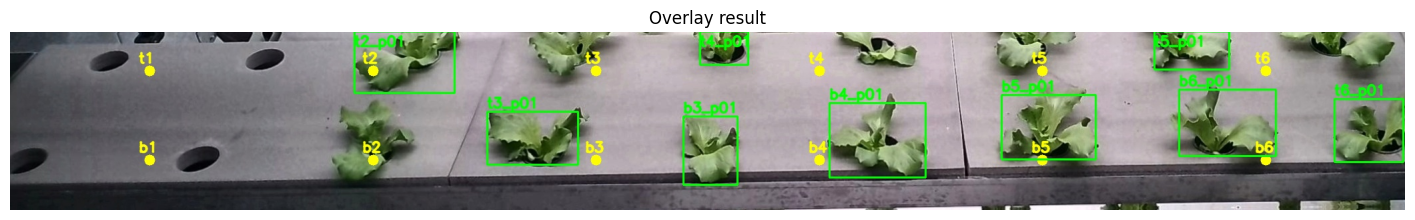

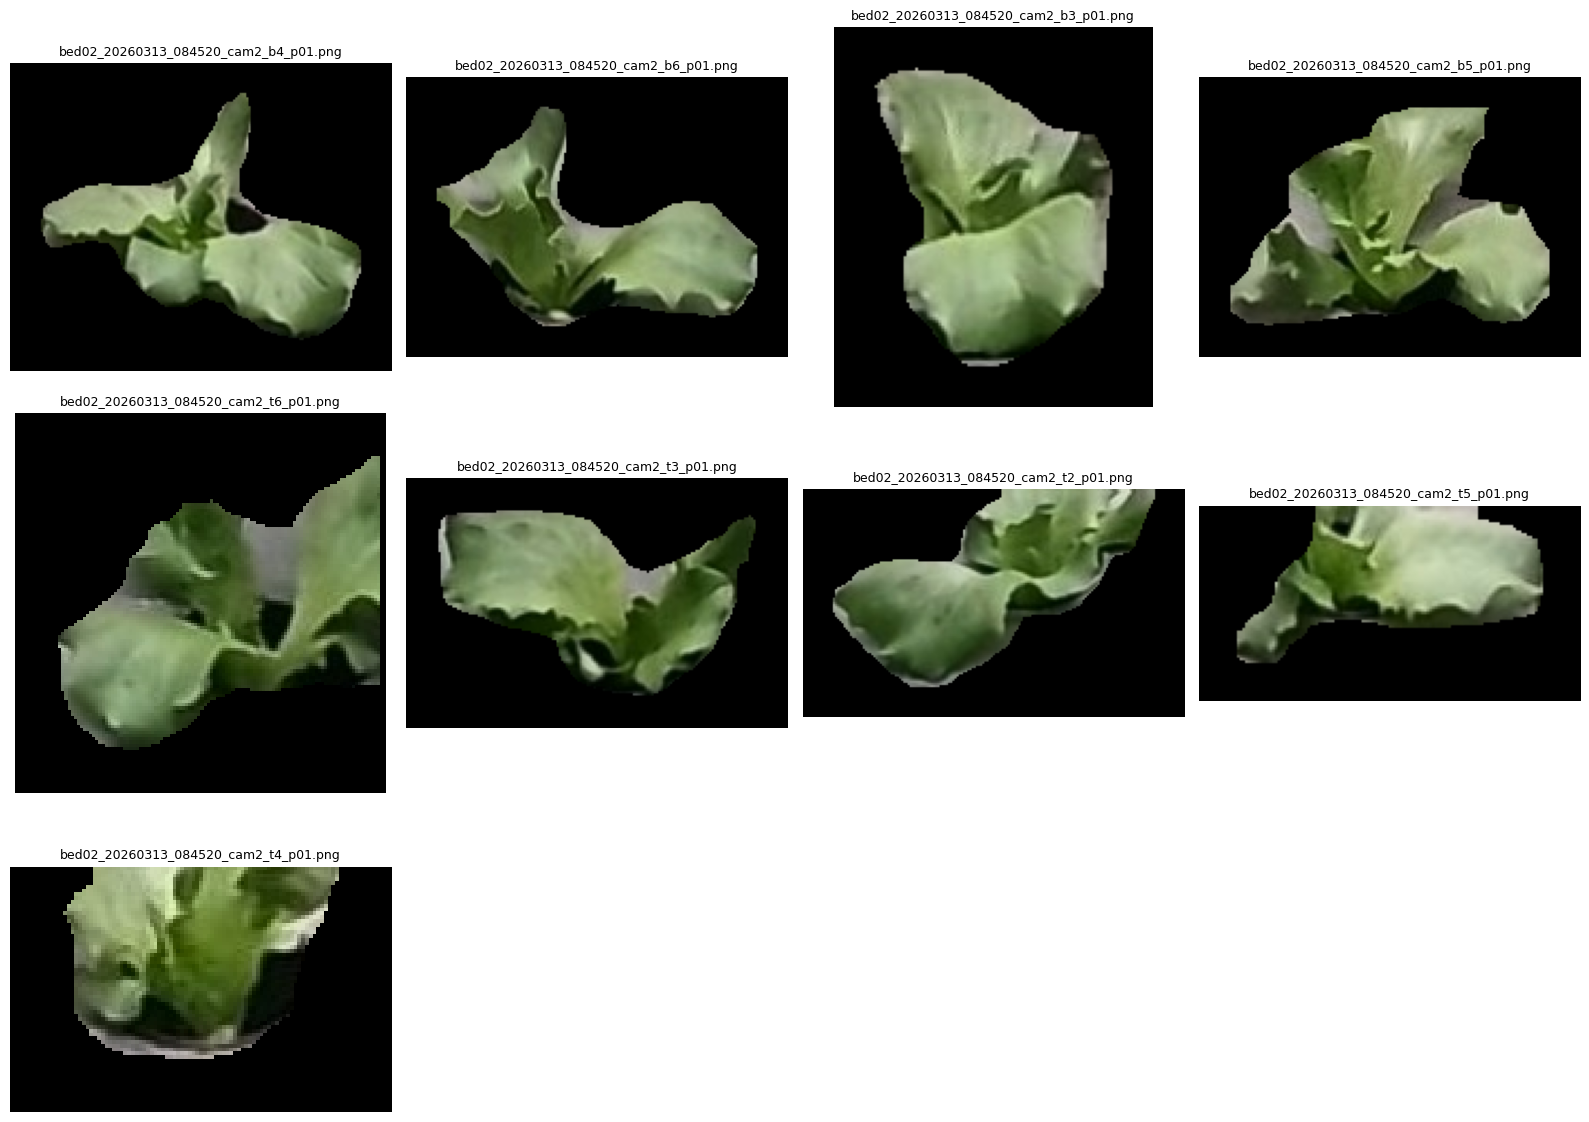

In [ ]:
# =========================================
# TEST: bed 이미지 1장만 돌려서 결과 확인
# =========================================
from matplotlib import pyplot as plt
from pathlib import Path
import os
import cv2

# 1) 테스트할 이미지 1장 지정
TEST_IMG_PATH = r"/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/2. ROI_BOX/2작기/5. 밝기보정/testimage/bed02_20260313_084520_cam2.jpg"

# 또는 자동으로 첫 장 가져오려면 이거 사용
# img_list = list_images_recursive(IMG_ROOT)
# TEST_IMG_PATH = img_list[0]

print("TEST_IMG_PATH:", TEST_IMG_PATH)

# Fix: Set DEVICE to 'cpu' as GPU is not available
DEVICE = 'cpu'
print(f"[INFO] DEVICE set to: {DEVICE}")

# 2) 모델 로드
model = YOLO(MODEL_PATH)

# 3) 1장 처리
ret = process_one_image(TEST_IMG_PATH, model)

print("\n[RESULT SUMMARY]")
print("n_det   :", ret["n_det"])
print("n_saved :", ret["n_saved"])
print("n_fail  :", ret["n_fail"])
print("error   :", ret["error"])
print("overlay :", ret["overlay_path"])

# 4) metadata 미리 보기
df_test = pd.DataFrame(ret["meta_rows"])
print("\n[METADATA HEAD]")
display(df_test.head(20))

# 5) overlay 출력
if ret["overlay_path"] is not None and os.path.exists(ret["overlay_path"]):
    overlay_bgr = cv2.imread(ret["overlay_path"])
    overlay_rgb = cv2.cvtColor(overlay_bgr, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(18, 8))
    plt.imshow(overlay_rgb)
    plt.title("Overlay result")
    plt.axis("off")
    plt.show()
else:
    print("overlay image not found")

# 6) 저장된 crop 몇 장 출력
crop_paths = [p for p in df_test["crop_path"].dropna().tolist() if os.path.exists(p)]
crop_paths = crop_paths[:12]   # 최대 12장만 보기

if len(crop_paths) == 0:
    print("saved crop image not found")
else:
    n = len(crop_paths)
    cols = 4
    rows = (n + cols - 1) // cols

    plt.figure(figsize=(16, 4 * rows))
    for i, cp in enumerate(crop_paths, start=1):
        img_bgr = cv2.imread(cp)
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

        plt.subplot(rows, cols, i)
        plt.imshow(img_rgb)
        plt.title(Path(cp).name, fontsize=9)
        plt.axis("off")
    plt.tight_layout()
    plt.show()

#상추 재 필터링 (결구판단용)

In [ ]:
# ============================================================
# QC filter + copy lettuce crops by date
# - input : slot_crop_metadata_all.csv
# - output: 날짜별 폴더에 통과 crop 이미지 복사 + qc 결과 csv 저장
# ============================================================

import os
import re
import math
import shutil
import pandas as pd
from pathlib import Path
from tqdm.auto import tqdm

# ============================================================
# 1) 경로 설정 (여기만 수정)
# ============================================================
META_CSV = r"/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/3. ROI_LETTUCE/1.5작기_lettuce/slot_crop_metadata_all.csv"
QC_OUT_ROOT = r"/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/3. ROI_LETTUCE/1.5작기_lettuce/crops_filter(1)"

# ============================================================
# 2) QC 기준 설정 (여기만 수정)
# ============================================================
MIN_DATE = 251213          # 이 날짜 이상만 사용
MIN_BBOX_Y1 = 100          # bbox_y1 < 100 이면 제외
MIN_AR = 0.50             # aspect_ratio = bbox_w / bbox_h 최소
MAX_AR = 2.00             # aspect_ratio 최대
ONLY_PRIMARY = False      # True면 is_primary==1 만 사용
KEEP_STATUSES = ["ok"]   # status가 이 값들인 행만 사용

# 파일 존재 여부 확인
CHECK_FILE_EXISTS = True

# 복사 방식
COPY_MODE = "copy"       # "copy" 또는 "move" (보통 copy 유지)

# 결과 저장
SAVE_FILTERED_CSV = True
SAVE_EXCLUDED_CSV = True


In [ ]:

# ============================================================
# 3) 유틸 함수
# ============================================================
def safe_mkdir(p):
    os.makedirs(p, exist_ok=True)


def to_int_safe(x):
    try:
        if pd.isna(x):
            return None
        return int(float(x))
    except:
        return None


def parse_date_from_basekey(base_key):
    """
    예: bed13_20251224_074242_cam2 -> 251224 반환
    """
    if pd.isna(base_key):
        return None
    m = re.search(r"_(\d{8})_", str(base_key))
    if not m:
        return None
    yyyymmdd = m.group(1)
    return int(yyyymmdd[2:])  # 20251224 -> 251224


def file_exists_safe(p):
    try:
        return isinstance(p, str) and len(p) > 0 and os.path.exists(p)
    except:
        return False


def copy_or_move(src, dst, mode="copy"):
    safe_mkdir(os.path.dirname(dst))
    if mode == "move":
        shutil.move(src, dst)
    else:
        shutil.copy2(src, dst)


# ============================================================
# 4) 메타 csv 로드
# ============================================================
print("[INFO] loading:", META_CSV)
df = pd.read_csv(META_CSV)
print("[INFO] rows:", len(df))
print("[INFO] columns:", list(df.columns))

# 필수 컬럼 확인
required_cols = ["base_key", "crop_path", "bbox_y1", "bbox_w", "bbox_h"]
missing_cols = [c for c in required_cols if c not in df.columns]
if missing_cols:
    raise ValueError(f"필수 컬럼 없음: {missing_cols}")

# ============================================================
# 5) 날짜 / aspect_ratio / 파일존재 컬럼 준비
# ============================================================
if "date_6" not in df.columns:
    df["date_6"] = df["base_key"].apply(parse_date_from_basekey)

if "aspect_ratio_calc" not in df.columns:
    df["aspect_ratio_calc"] = df["bbox_w"] / df["bbox_h"]

# 기존 aspect_ratio 컬럼이 있어도 여기선 계산값을 기본으로 사용
# 이유: crop qc에서는 실제 bbox_w, bbox_h 기반이 더 명확함

df["bbox_y1_int"] = df["bbox_y1"].apply(to_int_safe)

df["file_exists"] = df["crop_path"].apply(file_exists_safe) if CHECK_FILE_EXISTS else True

# ============================================================
# 6) 제외 사유 기록용 함수
# ============================================================
def get_exclude_reason(row):
    date_6 = row.get("date_6")
    bbox_y1 = row.get("bbox_y1_int")
    ar = row.get("aspect_ratio_calc")
    status = row.get("status")
    is_primary = row.get("is_primary")
    exists = row.get("file_exists")

    if pd.isna(date_6) or date_6 is None:
        return "date_parse_fail"
    if int(date_6) < MIN_DATE:
        return "date_too_early"
    if pd.isna(bbox_y1) or bbox_y1 is None:
        return "bbox_y1_missing"
    if int(bbox_y1) < MIN_BBOX_Y1:
        return "bbox_y1_too_small"
    if pd.isna(ar):
        return "aspect_ratio_missing"
    if ar < MIN_AR:
        return "aspect_ratio_too_tall"
    if ar > MAX_AR:
        return "aspect_ratio_too_wide"
    if KEEP_STATUSES is not None and len(KEEP_STATUSES) > 0:
        if str(status) not in KEEP_STATUSES:
            return "status_filtered"
    if ONLY_PRIMARY:
        try:
            if int(is_primary) != 1:
                return "not_primary"
        except:
            return "not_primary"
    if CHECK_FILE_EXISTS and not exists:
        return "file_missing"
    return "keep"


# ============================================================
# 7) QC 적용
# ============================================================
df["qc_reason"] = df.apply(get_exclude_reason, axis=1)
df_keep = df[df["qc_reason"] == "keep"].copy()
df_excl = df[df["qc_reason"] != "keep"].copy()

print("\n[QC SUMMARY]")
print("keep rows   :", len(df_keep))
print("exclude rows:", len(df_excl))
print("\n[EXCLUDE REASONS]")
print(df["qc_reason"].value_counts(dropna=False))

# ============================================================
# 8) 날짜별 폴더 복사 저장
# ============================================================
safe_mkdir(QC_OUT_ROOT)

copied = 0
copy_fail = 0
failed_logs = []

for _, row in tqdm(df_keep.iterrows(), total=len(df_keep), desc="copy by date"):
    src = row["crop_path"]
    date_6 = int(row["date_6"])
    fname = os.path.basename(src)

    out_dir = os.path.join(QC_OUT_ROOT, str(date_6))
    safe_mkdir(out_dir)
    dst = os.path.join(out_dir, fname)

    try:
        copy_or_move(src, dst, mode=COPY_MODE)
        copied += 1
    except Exception as e:
        copy_fail += 1
        failed_logs.append({
            "crop_path": src,
            "out_path": dst,
            "error": str(e)
        })

print("\n[COPY SUMMARY]")
print("copied   :", copied)
print("copy_fail:", copy_fail)
print("QC_OUT_ROOT:", QC_OUT_ROOT)

# ============================================================
# 9) 결과 csv 저장
# ============================================================
if SAVE_FILTERED_CSV:
    out_keep_csv = os.path.join(QC_OUT_ROOT, "qc_keep.csv")
    df_keep.to_csv(out_keep_csv, index=False, encoding="utf-8-sig")
    print("saved:", out_keep_csv)

if SAVE_EXCLUDED_CSV:
    out_excl_csv = os.path.join(QC_OUT_ROOT, "qc_excluded.csv")
    df_excl.to_csv(out_excl_csv, index=False, encoding="utf-8-sig")
    print("saved:", out_excl_csv)

if len(failed_logs) > 0:
    out_fail_csv = os.path.join(QC_OUT_ROOT, "copy_failed.csv")
    pd.DataFrame(failed_logs).to_csv(out_fail_csv, index=False, encoding="utf-8-sig")
    print("saved:", out_fail_csv)

# 날짜별 개수 요약
summary = (
    df_keep.groupby("date_6")
    .size()
    .reset_index(name="n_keep")
    .sort_values("date_6")
)
out_summary_csv = os.path.join(QC_OUT_ROOT, "qc_keep_summary_by_date.csv")
summary.to_csv(out_summary_csv, index=False, encoding="utf-8-sig")
print("saved:", out_summary_csv)

print("\n[DONE]")

[INFO] loading: /content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/3. ROI_LETTUCE/1.5작기_lettuce/slot_crop_metadata_all.csv
[INFO] rows: 4326
[INFO] columns: ['image_path', 'base_key', 'bed_name', 'slot_name', 'part_no', 'crop_filename', 'crop_path', 'conf', 'cls', 'cx', 'cy', 'bbox_x1', 'bbox_y1', 'bbox_x2', 'bbox_y2', 'bbox_w', 'bbox_h', 'area_px', 'mask_pixels', 'is_primary', 'n_det_in_image', 'status']

[QC SUMMARY]
keep rows   : 1088
exclude rows: 3238

[EXCLUDE REASONS]
qc_reason
date_too_early           2649
keep                     1088
bbox_y1_too_small         426
aspect_ratio_too_tall     154
aspect_ratio_too_wide       9
Name: count, dtype: int64


copy by date:   0%|          | 0/1088 [00:00<?, ?it/s]


[COPY SUMMARY]
copied   : 1088
copy_fail: 0
QC_OUT_ROOT: /content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/3. ROI_LETTUCE/1.5작기_lettuce/crops_filter(1)
saved: /content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/3. ROI_LETTUCE/1.5작기_lettuce/crops_filter(1)/qc_keep.csv
saved: /content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/3. ROI_LETTUCE/1.5작기_lettuce/crops_filter(1)/qc_excluded.csv
saved: /content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/3. ROI_LETTUCE/1.5작기_lettuce/crops_filter(1)/qc_keep_summary_by_date.csv

[DONE]
